# **Data-Driven Prioritization and Response Optimization for Toronto 311 Service Requests**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
#load dataset
df = pd.read_csv("/content/drive/MyDrive/Seneca Terms/Winter 2026/BDC800/311_requests_2024-2025.csv")
df.head()

,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
0,2024-01-01 00:10:57,Completed,M4A,NaN,NaN,Beaches-East York (19),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
1,2024-01-01 00:20:03,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),Fireworks,Municipal Licensing & Standards,Parks Enforcement
2,2024-01-01 00:29:48,Unknown,M6C,NaN,NaN,Toronto-St. Paul's (12),Business Complaint,Municipal Licensing & Standards,Business Licensing Enforcement
3,2024-01-01 00:37:32,Unknown,M1R,NaN,NaN,Scarborough Centre (21),Unknown - MLSBLEMMVN,Unknown,Unknown
4,2024-01-01 00:52:35,Completed,M3M,NaN,NaN,York Centre (06),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement


In [ ]:
df.shape
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866904 entries, 0 to 866903
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Creation Date                 866904 non-null  object
 1   Status                        866904 non-null  object
 2   First 3 Chars of Postal Code  866904 non-null  object
 3   Intersection Street 1         136097 non-null  object
 4   Intersection Street 2         135055 non-null  object
 5   Ward                          866904 non-null  object
 6   Service Request Type          866904 non-null  object
 7   Division                      866904 non-null  object
 8   Section                       866904 non-null  object
dtypes: object(9)
memory usage: 59.5+ MB


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
count,866904,866904,866904,136097,135055,866904,866904,866904,866904
unique,854955,6,101,6438,5851,26,768,7,21
top,2024-12-08 06:44:39,Completed,Intersection,Bathurst St,Canyon Ave,Toronto-Danforth (14),Injured - Wildlife,Solid Waste Management Services,Collections
freq,12,694786,136097,5396,3478,53604,34184,324712,322183


Standardize Column Names

In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

df.columns

Index(['creation_date', 'status', 'first_3_chars_of_postal_code',
       'intersection_street_1', 'intersection_street_2', 'ward',
       'service_request_type', 'division', 'section'],
      dtype='object')

Remove Duplicates

In [ ]:
df = df.drop_duplicates()
df.shape

(865712, 9)

Check missing values

In [ ]:
df.isnull().sum()

,0
creation_date,0
status,0
first_3_chars_of_postal_code,0
intersection_street_1,729796
intersection_street_2,730838
ward,0
service_request_type,0
division,0
section,0


Handle Missing Values

In [ ]:
df = df.dropna(subset=["creation_date", "service_request_type"])
df.head()

,creation_date,status,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section
0,2024-01-01 00:10:57,Completed,M4A,NaN,NaN,Beaches-East York (19),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement
1,2024-01-01 00:20:03,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),Fireworks,Municipal Licensing & Standards,Parks Enforcement
2,2024-01-01 00:29:48,Unknown,M6C,NaN,NaN,Toronto-St. Paul's (12),Business Complaint,Municipal Licensing & Standards,Business Licensing Enforcement
3,2024-01-01 00:37:32,Unknown,M1R,NaN,NaN,Scarborough Centre (21),Unknown - MLSBLEMMVN,Unknown,Unknown
4,2024-01-01 00:52:35,Completed,M3M,NaN,NaN,York Centre (06),Amplified Sound,Municipal Licensing & Standards,Bylaw Enforcement


In [ ]:
df["ward"] = df["ward"].fillna("Unknown")
df["status"] = df["status"].fillna("Open") #fill this fileds

Date Cleaning

In [ ]:
df["creation_date"] = pd.to_datetime(df["creation_date"], errors="coerce")
df = df.dropna(subset=["creation_date"])

Time-Based Features (FOR PRIORITIZATION)

In [ ]:
df["request_hour"] = df["creation_date"].dt.hour
df["request_day"] = df["creation_date"].dt.dayofweek
df["request_month"] = df["creation_date"].dt.month
df["request_year"] = df["creation_date"].dt.year

In [ ]:
df["is_peak_hour"] = df["request_hour"].between(7, 10) | df["request_hour"].between(16, 19)
#peak hour flag

Clean Service Request Types

In [ ]:
df["service_request_type"] = (
    df["service_request_type"]
    .str.lower()
    .str.strip()
)
df.head()

,creation_date,status,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section,request_hour,request_day,request_month,request_year,is_peak_hour
0,2024-01-01 00:10:57,Completed,M4A,NaN,NaN,Beaches-East York (19),amplified sound,Municipal Licensing & Standards,Bylaw Enforcement,0,0,1,2024,False
1,2024-01-01 00:20:03,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),fireworks,Municipal Licensing & Standards,Parks Enforcement,0,0,1,2024,False
2,2024-01-01 00:29:48,Unknown,M6C,NaN,NaN,Toronto-St. Paul's (12),business complaint,Municipal Licensing & Standards,Business Licensing Enforcement,0,0,1,2024,False
3,2024-01-01 00:37:32,Unknown,M1R,NaN,NaN,Scarborough Centre (21),unknown - mlsblemmvn,Unknown,Unknown,0,0,1,2024,False
4,2024-01-01 00:52:35,Completed,M3M,NaN,NaN,York Centre (06),amplified sound,Municipal Licensing & Standards,Bylaw Enforcement,0,0,1,2024,False


In [ ]:
#group rare types
top_services = df["service_request_type"].value_counts().nlargest(15).index

df["service_request_type"] = df["service_request_type"].where(
    df["service_request_type"].isin(top_services),
    "other"
)

Postal Code Cleaning (Equity Analysis)

In [ ]:
df["first_3_chars_of_postal_code"] = (
    df["first_3_chars_of_postal_code"]
    .astype(str)
    .str.upper()
    .str.strip()
)
df.head()

,creation_date,status,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section,request_hour,request_day,request_month,request_year,is_peak_hour
0,2024-01-01 00:10:57,Completed,M4A,NaN,NaN,Beaches-East York (19),other,Municipal Licensing & Standards,Bylaw Enforcement,0,0,1,2024,False
1,2024-01-01 00:20:03,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),other,Municipal Licensing & Standards,Parks Enforcement,0,0,1,2024,False
2,2024-01-01 00:29:48,Unknown,M6C,NaN,NaN,Toronto-St. Paul's (12),other,Municipal Licensing & Standards,Business Licensing Enforcement,0,0,1,2024,False
3,2024-01-01 00:37:32,Unknown,M1R,NaN,NaN,Scarborough Centre (21),other,Unknown,Unknown,0,0,1,2024,False
4,2024-01-01 00:52:35,Completed,M3M,NaN,NaN,York Centre (06),other,Municipal Licensing & Standards,Bylaw Enforcement,0,0,1,2024,False


Backlog Feature

In [ ]:
df = df.sort_values("creation_date")

df["daily_backlog"] = (
    df.groupby(df["creation_date"].dt.date)
      .cumcount()
)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 865712 entries, 0 to 866903
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   creation_date                 865712 non-null  datetime64[ns]
 1   status                        865712 non-null  object        
 2   first_3_chars_of_postal_code  865712 non-null  object        
 3   intersection_street_1         135916 non-null  object        
 4   intersection_street_2         134874 non-null  object        
 5   ward                          865712 non-null  object        
 6   service_request_type          865712 non-null  object        
 7   division                      865712 non-null  object        
 8   section                       865712 non-null  object        
 9   request_hour                  865712 non-null  int32         
 10  request_day                   865712 non-null  int32         
 11  request_month     

,creation_date,status,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section,request_hour,request_day,request_month,request_year,is_peak_hour,daily_backlog
0,2024-01-01 00:10:57,Completed,M4A,NaN,NaN,Beaches-East York (19),other,Municipal Licensing & Standards,Bylaw Enforcement,0,0,1,2024,False,0
1,2024-01-01 00:20:03,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),other,Municipal Licensing & Standards,Parks Enforcement,0,0,1,2024,False,1
2,2024-01-01 00:29:48,Unknown,M6C,NaN,NaN,Toronto-St. Paul's (12),other,Municipal Licensing & Standards,Business Licensing Enforcement,0,0,1,2024,False,2
3,2024-01-01 00:37:32,Unknown,M1R,NaN,NaN,Scarborough Centre (21),other,Unknown,Unknown,0,0,1,2024,False,3
4,2024-01-01 00:52:35,Completed,M3M,NaN,NaN,York Centre (06),other,Municipal Licensing & Standards,Bylaw Enforcement,0,0,1,2024,False,4


## **EDA**

In [ ]:
plt.style.use("default")
sns.set_palette("Set2")

### Overall Demand Patterns

Requests per Day

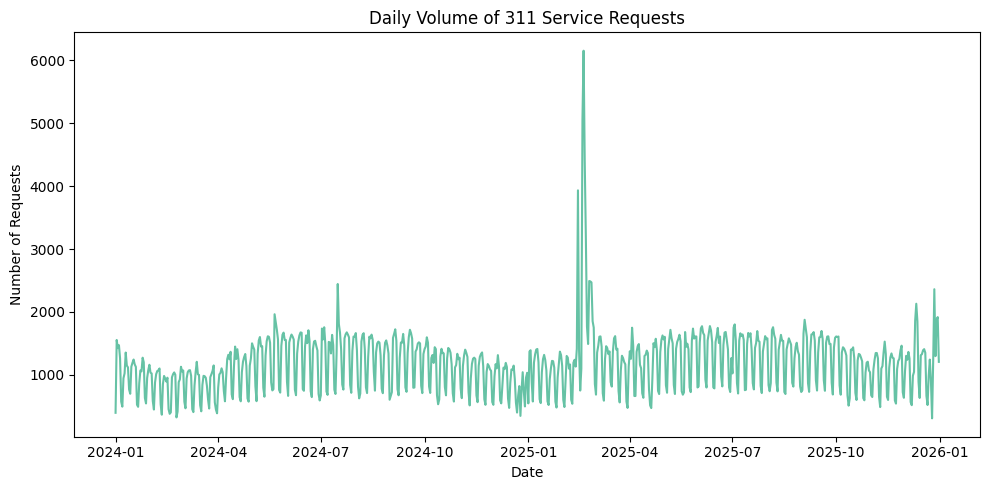

In [ ]:
daily_requests = (
    df.groupby(df["creation_date"].dt.date)
      .size()
)

plt.figure(figsize=(10,5))
daily_requests.plot()
plt.title("Daily Volume of 311 Service Requests")
plt.xlabel("Date")
plt.ylabel("Number of Requests")
plt.tight_layout()
plt.show()


I chose a line graph to effectively track temporal trends and identify anomalies that deviate from the regular weekly seasonality. The most significant finding is the massive surge in February 2025, where requests spiked to over 6,000; my investigation confirms this was the direct result of a major snowstorm, reflecting a sudden, critical demand for city services.

Requests per Month

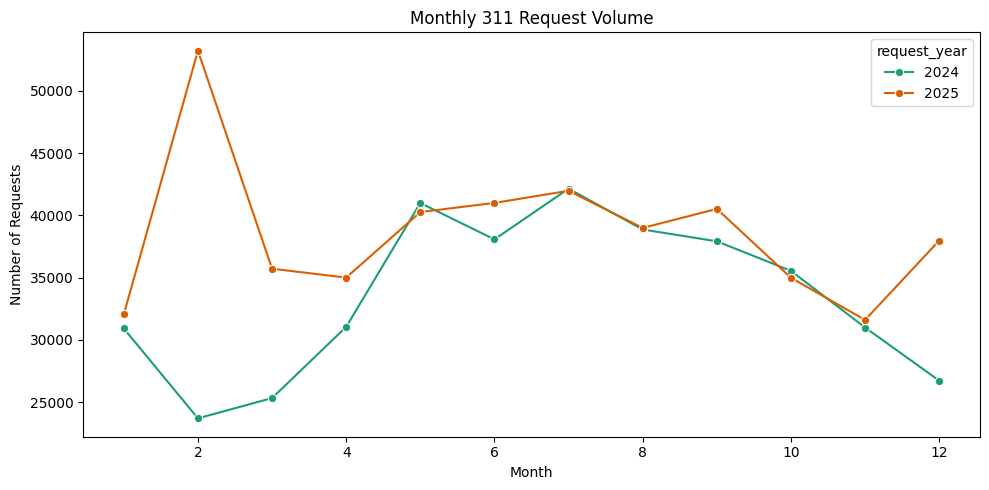

In [ ]:
monthly_requests = (
    df.groupby(["request_year", "request_month"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_requests,
    x="request_month",
    y="count",
    hue="request_year",
    marker="o",
    palette="Dark2"
)
plt.title("Monthly 311 Request Volume")
plt.xlabel("Month")
plt.ylabel("Number of Requests")
plt.tight_layout()
plt.show()


used a multi-line plot with markers to visualize how service demand shifts seasonally, making it easy to see that while both years follow a similar "summer peak" pattern, February 2025 is a major outlier. By aggregating the data monthly, I was able to confirm that the snowstorm wasn't just a daily spike, but an event significant enough to drive the highest monthly volume in the entire two-year dataset.

Requests by Hour of Day

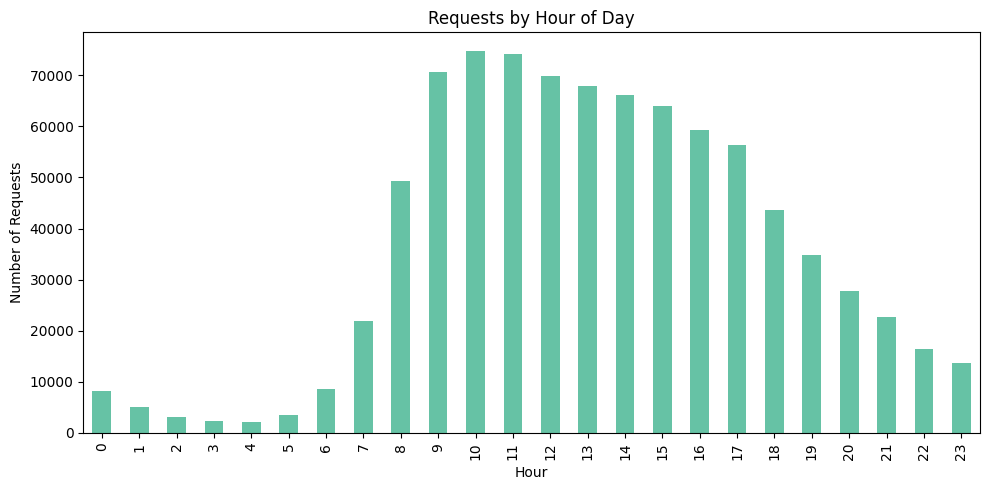

In [ ]:
hourly_requests = df["request_hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
hourly_requests.plot(kind="bar")
plt.title("Requests by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Requests")
plt.tight_layout()
plt.show()

used a bar chart to highlight the city's daily operational rhythm, which shows a consistent baseline of activity during late-night hours. These overnight submissions are driven by the 24/7 online portal, allowing residents to report issues at any time regardless of call center hours.

### Service Request Type Analysis

Top 10 Services by Volume fix

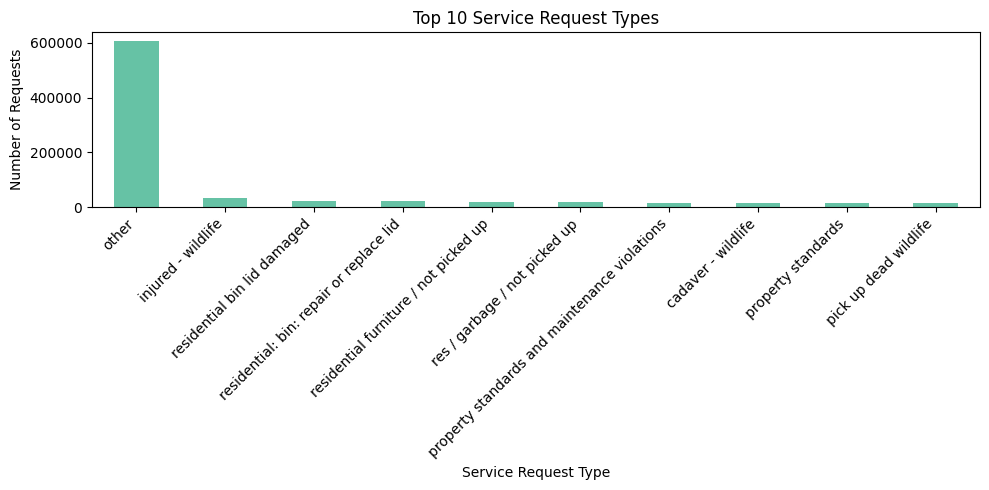

In [ ]:
top_services = df["service_request_type"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_services.plot(kind="bar")
plt.title("Top 10 Service Request Types")
plt.xlabel("Service Request Type")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


This bar chart ranks the top 10 service request types, revealing that "other" accounts for the vast majority of submissions.

A bar chart was used to highlight the disparity between general and specific categories, such as wildlife-related issues and residential waste. The dominance of the "other" category suggests a high volume of unique requests that fall outside standard classifications, indicating a potential need for more granular labeling within the reporting system.

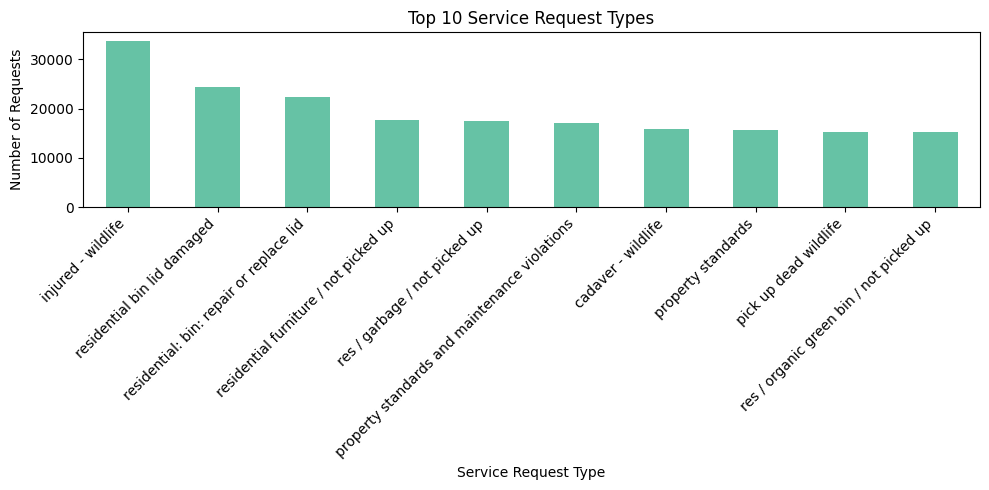

'Other' category count: 607,674


In [ ]:
service_counts = df["service_request_type"].value_counts()

top_services = service_counts[service_counts.index != "other"].head(10)

plt.figure(figsize=(10,5))
top_services.plot(kind="bar")
plt.title("Top 10 Service Request Types")
plt.xlabel("Service Request Type")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"'Other' category count: {service_counts['other']:,}")


This bar chart highlights the top 10 specific service request types, intentionally excluding the "other" category to focus on actionable data.

A bar chart was selected to rank identified issues, revealing that "injured - wildlife" is the single most frequent specific request. The visualization shows a high concentration of needs related to residential waste management, such as bin repairs and missed pickups which indicates these are the primary areas where residents seek direct municipal intervention.

Service Type & Hour Heatmap

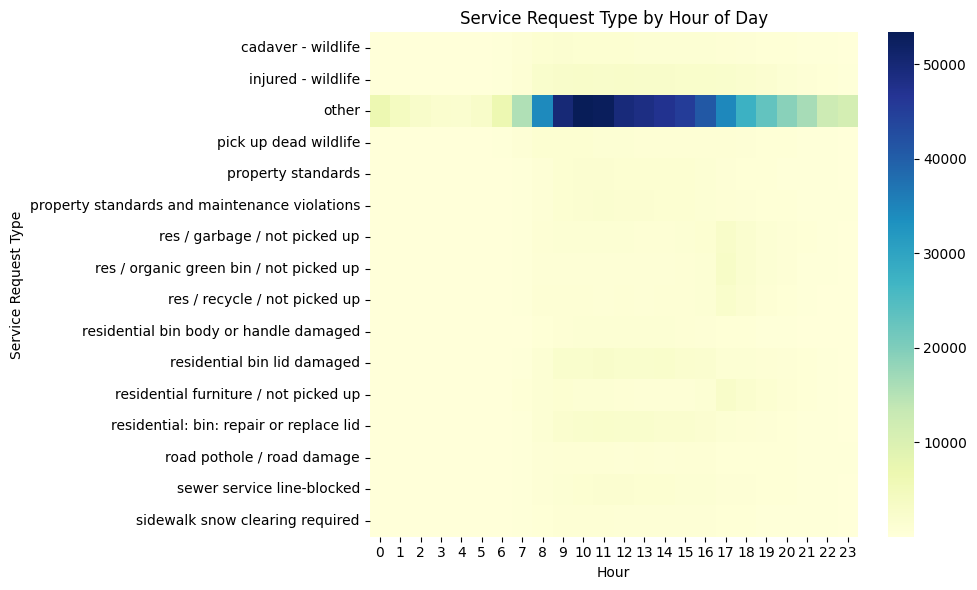

In [ ]:
service_hour = (
    df.groupby(["service_request_type", "request_hour"])
      .size()
      .reset_index(name="count")
)

pivot_service_hour = service_hour.pivot(
    index="service_request_type",
    columns="request_hour",
    values="count"
).fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_service_hour, cmap="YlGnBu")
plt.title("Service Request Type by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Service Request Type")
plt.tight_layout()
plt.show()


This heatmap identifies peak submission times for various request types, highlighting that activity is most concentrated between 8:00 AM and 4:00 PM.

The format effectively visualizes density, showing that while "other" dominates the midday, categories like missed garbage pickups see a slight uptick in the late afternoon. This suggests a pattern of residents reporting household issues immediately upon returning from work.

Service Type & Day of Week

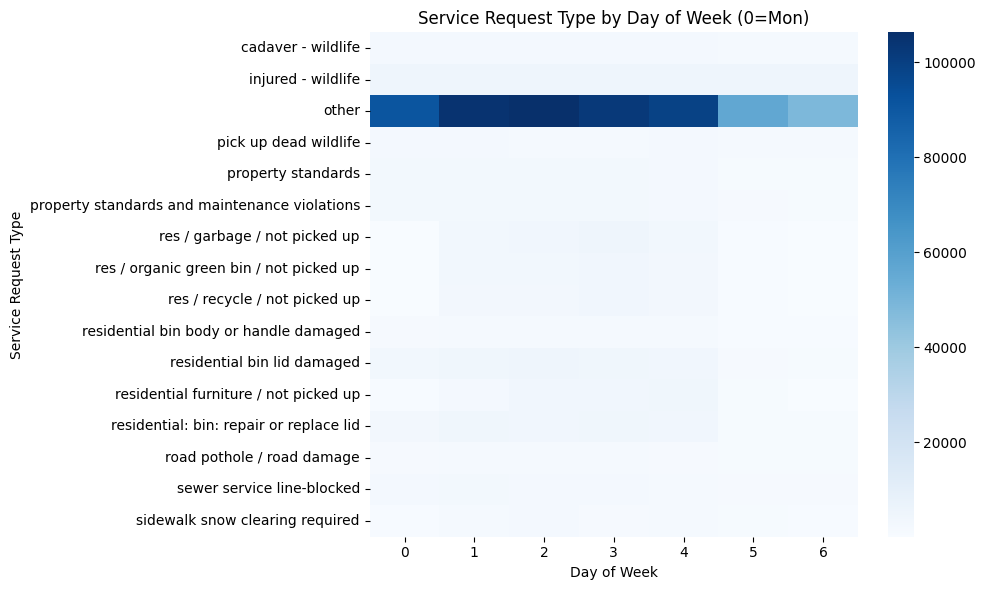

In [ ]:
service_day = (
    df.groupby(["service_request_type", "request_day"])
      .size()
      .reset_index(name="count")
)

pivot_service_day = service_day.pivot(
    index="service_request_type",
    columns="request_day",
    values="count"
).fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_service_day, cmap="Blues")
plt.title("Service Request Type by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Service Request Type")
plt.tight_layout()
plt.show()


This heatmap demonstrates that service requests are most concentrated during the standard work week (Monday–Friday), with a noticeable decline during the weekend.

The format highlights that while the "other" category drives the majority of weekday volume, specific issues like residential waste and snow clearing remain relatively consistent across all seven days. This suggests that residents are more likely to engage with municipal services during business days, even for non-emergency reports.

### Ward-Level & Equity Analysis

Requests per Ward

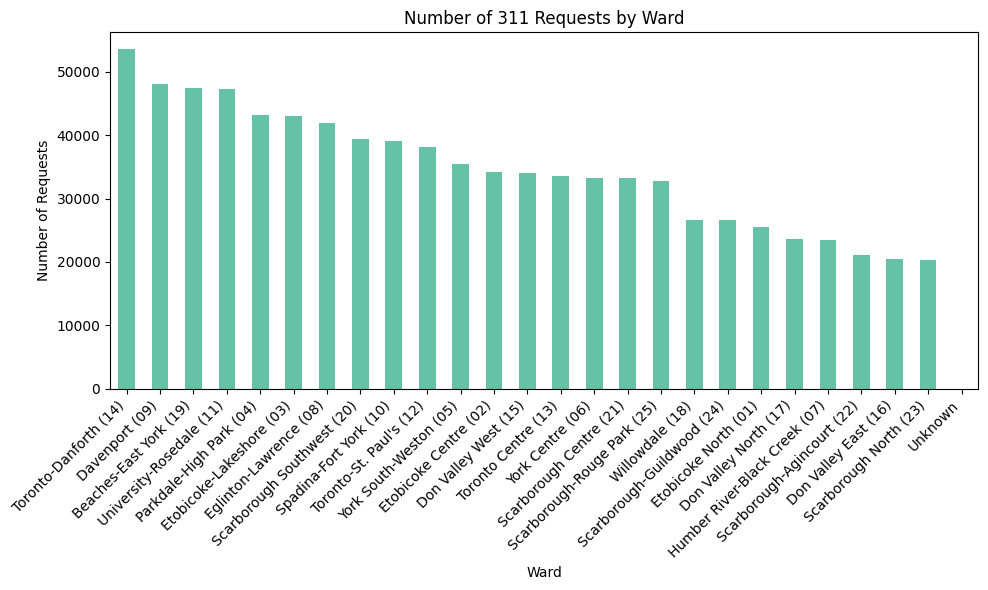

In [ ]:
ward_counts = df["ward"].value_counts()

plt.figure(figsize=(10,6))
ward_counts.plot(kind="bar")
plt.title("Number of 311 Requests by Ward")
plt.xlabel("Ward")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The bar chart format highlights a clear geographic disparity in service demand, showing that the top four wards account for a significantly higher portion of total requests. This visualization is essential for identifying which regions may require more concentrated municipal resources or infrastructure improvements based on resident reporting trends.

Ward & Service Type Heatmap (Top Services Only)

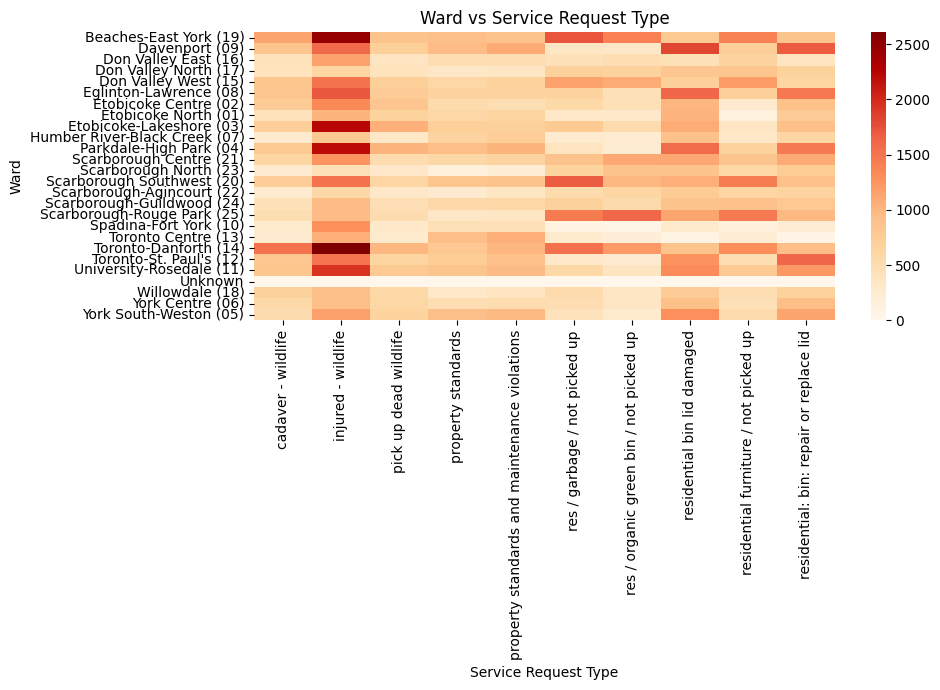

In [ ]:
top_services_list = top_services.index

ward_service = (
    df[df["service_request_type"].isin(top_services_list)]
    .groupby(["ward", "service_request_type"])
    .size()
    .reset_index(name="count")
)

pivot_ward_service = ward_service.pivot(
    index="ward",
    columns="service_request_type",
    values="count"
).fillna(0)

plt.figure(figsize=(10,7))
sns.heatmap(pivot_ward_service, cmap="OrRd")
plt.title("Ward vs Service Request Type")
plt.xlabel("Service Request Type")
plt.ylabel("Ward")
plt.tight_layout()
plt.show()


This heatmap reveals how specific service request types are distributed across different wards, identifying localized patterns of municipal concern.

The visualization highlights that "injured - wildlife" is a dominant issue across nearly all wards, with the highest concentrations in areas like Toronto-Danforth (14) and Beaches-East York (19). By cross-referencing geography with request types, this chart identifies which wards are most affected by specific infrastructure or environmental issues, such as bin damage or waste collection delays.

### System Pressure Proxy

Distribution of Daily Request Sequence

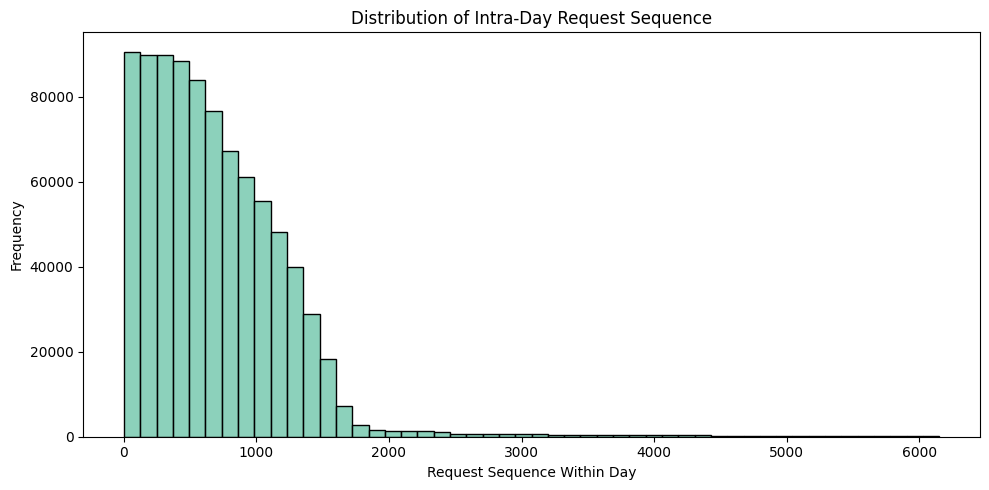

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["daily_backlog"], bins=50)
plt.title("Distribution of Intra-Day Request Sequence")
plt.xlabel("Request Sequence Within Day")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


This histogram illustrates the distribution of daily request sequences, showing a significant right-skewed pattern.

The chart was chosen to visualize the frequency of various workload volumes. Most days see a "backlog" or sequence count below 1,500, while the long tail represents rare, extreme events—like the previously identified February snowstorm—where the daily volume drastically exceeds the typical operational capacity.

Average Request Sequence by Hour

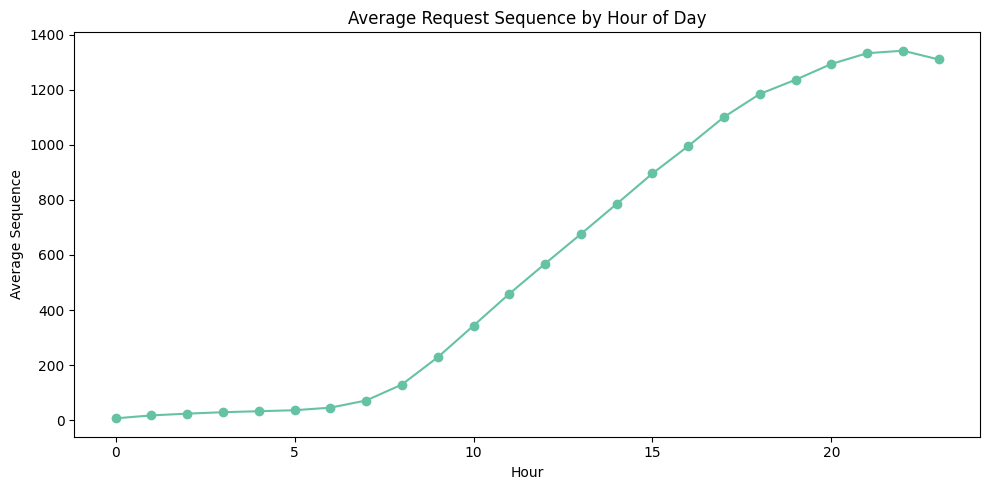

In [ ]:
avg_sequence_hour = (
    df.groupby("request_hour")["daily_backlog"]
      .mean()
)

plt.figure(figsize=(10,5))
avg_sequence_hour.plot(marker="o")
plt.title("Average Request Sequence by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Sequence")
plt.tight_layout()
plt.show()


This line chart illustrates the daily accumulation of requests, highlighting a steady "build-up" from early morning to a late-evening plateau.

The markers reveal that the sharpest acceleration in service demand occurs between 8:00 AM and 8:00 PM. This visualization effectively captures the continuous pressure on municipal systems during peak hours before activity tapers off toward midnight.

Request Sequence by Service Type

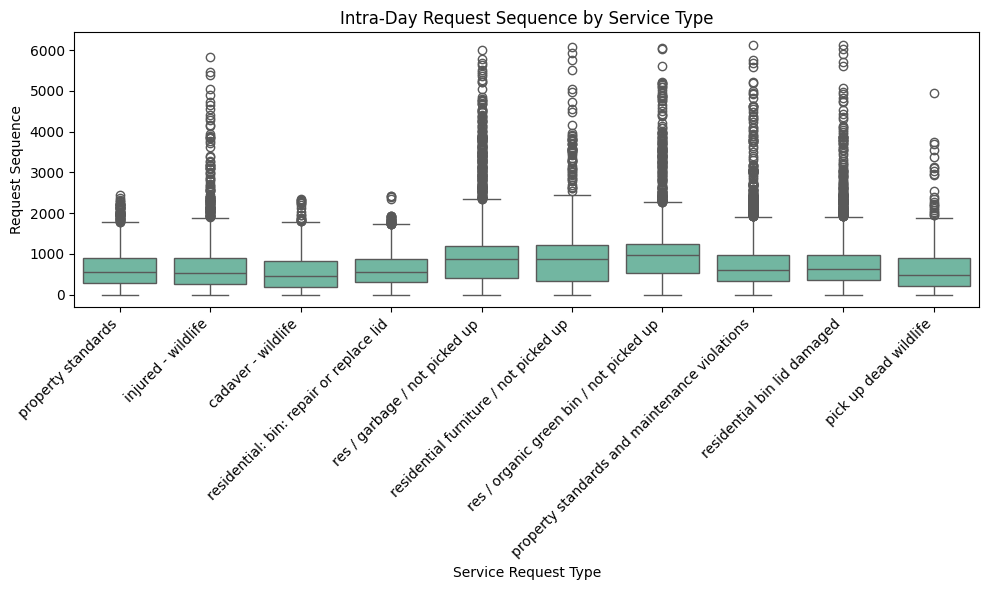

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df[df["service_request_type"].isin(top_services_list)],
    x="service_request_type",
    y="daily_backlog"
)
plt.title("Intra-Day Request Sequence by Service Type")
plt.xlabel("Service Request Type")
plt.ylabel("Request Sequence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


This boxplot compares the daily workload across request types, highlighting typical volumes and extreme outliers.

The format effectively visualizes variance, showing that while most categories maintain a median under 1,000, residential waste and furniture pickups frequently spike toward 6,000. These outliers indicate that waste-related issues are the primary drivers of high-volume days for city services.

### Feature Relationships

Request Sequence by Day of week

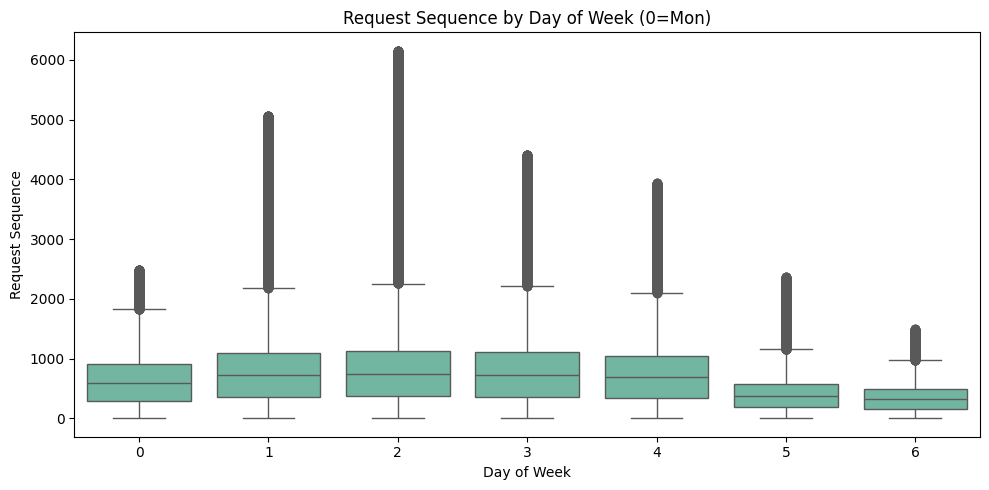

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="request_day",
    y="daily_backlog"
)
plt.title("Request Sequence by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Request Sequence")
plt.tight_layout()
plt.show()


Ward-Level System Pressure Comparison

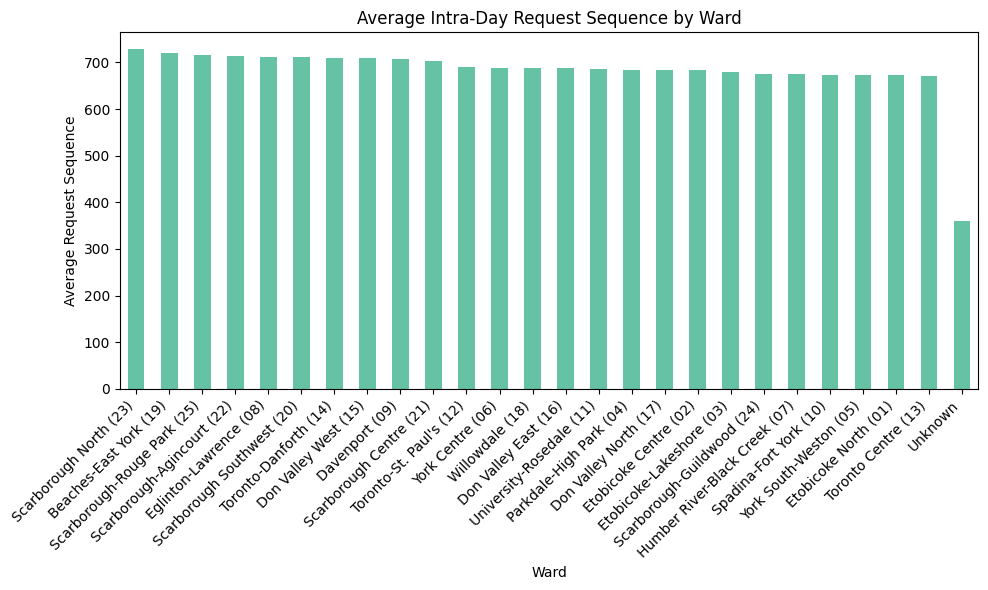

In [ ]:
avg_sequence_ward = (
    df.groupby("ward")["daily_backlog"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
avg_sequence_ward.plot(kind="bar")
plt.title("Average Intra-Day Request Sequence by Ward")
plt.xlabel("Ward")
plt.ylabel("Average Request Sequence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



Toronto 311 Service Request Prediction System

Goal:
Transform raw service request data into high-quality predictive features
while avoiding dimensional explosion.

# 2. Feature Engineering

# 2. Temporal Feature Engineering

## 2.1 Rationale

Time in urban systems is cyclical rather than linear.

Treating hour = 23 and hour = 0 as numerically distant introduces artificial discontinuity.

To preserve temporal continuity, we encode time using trigonometric transformations.


## 2.2 Cyclical Encoding Method

For a periodic variable x:

x_sin = sin(2πx / P)  
x_cos = cos(2πx / P)

Where P represents the period:
• 24 for hours
• 12 for months

This projects time onto a unit circle, preserving adjacency relationships.


## Why Do This?

### The Circular Nature of Time

In linear scale:
- Hour 23 and hour 0 are 23 units apart.

In reality:
- They are only 1 hour apart.

Cyclical encoding ensures that late-night (11 PM) is mathematically adjacent to early morning (12 AM).

### Model Benefit

• Captures overnight backlog patterns  
• Improves prediction of off-hour response delays  
• Prevents artificial discontinuity in time-based models  


In [ ]:
import numpy as np
import pandas as pd

# Ensure datetime features exist
df['creation_date'] = pd.to_datetime(df['creation_date'])
df['creation_hour'] = df['creation_date'].dt.hour
df['creation_month'] = df['creation_date'].dt.month

# Cyclical Encoding
df['hour_sin'] = np.sin(2 * np.pi * df['creation_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['creation_hour'] / 24)

df['month_sin'] = np.sin(2 * np.pi * df['creation_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['creation_month'] / 12)

df[['creation_hour','hour_sin','hour_cos']].head()


,creation_hour,hour_sin,hour_cos
0,0,0.0,1.0
1,0,0.0,1.0
2,0,0.0,1.0
3,0,0.0,1.0
4,0,0.0,1.0


## 2.3 Expected Modeling Benefit

Cyclical encoding:

• Prevents boundary distortion  
• Improves representation of overnight backlog effects  
• Enhances smooth decision boundaries in tree-based and linear models  

This is particularly important in municipal systems where late-night requests often spill into next-day operational queues.


# 3. High-Cardinality Categorical Encoding

## 3.1 Problem

The dataset contains:

• 44+ Wards  
• Hundreds of Service Request Types  

Naive one-hot encoding would create a high-dimensional sparse matrix,
increasing computational complexity and overfitting risk.


## 3.2 Frequency Encoding Strategy

Each categorical value is replaced with:

Frequency = Count(category) / Total Observations

This transforms categories into empirical demand intensity signals.


In [ ]:
# Frequency Encoding
for col in ['ward', 'service_request_type']:
    freq = df[col].value_counts(normalize=True)
    df[f'{col}_freq'] = df[col].map(freq)

df[['ward','ward_freq']].head()


,ward,ward_freq
0,Beaches-East York (19),0.054838
1,Etobicoke-Lakeshore (03),0.049634
2,Toronto-St. Paul's (12),0.044100
3,Scarborough Centre (21),0.038375
4,York Centre (06),0.038410


## 3.3 Theoretical Justification

Frequency encoding provides:

• Dimensionality reduction  
• Implicit demand weighting  
• Better generalization than ID encoding  

It converts nominal categories into economically meaningful signals
that reflect municipal workload distribution.


# 4. Lag-Based Backlog Features

## 4.1 Motivation

Service requests are temporally dependent.

A surge in requests today increases the likelihood of backlog tomorrow.

To capture operational strain, we construct rolling demand windows.


In [ ]:
# Make sure datetime
df['creation_date'] = pd.to_datetime(df['creation_date'])

# Sort properly
df = df.sort_values(['service_request_type', 'creation_date'])

def compute_rolling(group):
    group = group.copy()
    group = group.set_index('creation_date')

    group['rolling_3d_volume'] = group['status'].rolling('3D').count()
    group['rolling_7d_volume'] = group['status'].rolling('7D').count()

    return group.reset_index()

df = (
    df.groupby('service_request_type', group_keys=False)
      .apply(compute_rolling)
)

df[['rolling_3d_volume','rolling_7d_volume']].head()


/tmp/ipykernel_587/3299771913.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_rolling)


,rolling_3d_volume,rolling_7d_volume
0,1.0,1.0
1,2.0,2.0
2,3.0,3.0
3,4.0,4.0
4,5.0,5.0


## 4.2 Operational Interpretation

These lag features represent:

• Short-term demand shocks (3-day window)  
• Medium-term workload accumulation (7-day window)  

They provide temporal memory to the model,
allowing it to recognize periods of system stress.


# 5. Dimensionality Reduction via PCA

## 5.1 Purpose

Several engineered features are correlated:

• hour_sin & hour_cos  
• month_sin & month_cos  
• demand frequency features  

To eliminate multicollinearity and extract orthogonal structure,
we apply Principal Component Analysis (PCA).


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'ward_freq',
    'service_request_type_freq',
    'rolling_3d_volume',
    'rolling_7d_volume'
]

# Standardize
X_scaled = StandardScaler().fit_transform(df[pca_features].fillna(0))

# PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X_scaled)

df[['PC1','PC2','PC3']] = principal_components

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.3429581  0.16475533 0.1272644 ]


The first three principal components explain approximately 63.5% of total variance in the engineered feature space.

PC1 (34.3%) captures dominant urban demand intensity signals,
PC2 (16.5%) captures orthogonal temporal structure,
and PC3 (12.7%) reflects secondary seasonal or backlog-related variation.

This indicates that the majority of predictive structure can be represented in a reduced 3-dimensional orthogonal space,
supporting dimensionality reduction without substantial information loss.


In [ ]:
pd.DataFrame(pca.components_, columns=pca_features)


,hour_sin,hour_cos,month_sin,month_cos,ward_freq,service_request_type_freq,rolling_3d_volume,rolling_7d_volume
0,0.032180,0.009493,0.033456,-0.041837,0.013874,0.561239,0.575536,0.591254
1,-0.700940,0.705340,-0.012570,-0.096652,-0.035247,-0.005191,0.018270,0.008668
2,-0.077552,0.024944,0.724689,0.678898,-0.079931,0.020383,0.012070,-0.018369


# PCA Component Interpretation

The following table represents the PCA loading matrix.

Each row corresponds to a Principal Component (PC),
and each value indicates the contribution (weight) of a feature to that component.

Higher absolute values → stronger influence on that component.


## PC1 — Demand Intensity & Backlog Pressure (34.3% Variance)

Strong Positive Loadings:
- service_request_type_freq (0.561)
- rolling_3d_volume (0.576)
- rolling_7d_volume (0.591)

Moderate Positive:
- ward_freq (0.014)

Minor Temporal Influence:
- hour_sin (0.032)
- hour_cos (0.009)

### Interpretation

PC1 primarily captures overall demand intensity and backlog accumulation.

It reflects areas and service types experiencing high short-term and medium-term request volume.

This component represents system strain and workload pressure.

In practical terms:

Higher PC1 score → Higher demand concentration → Greater operational stress.


## PC2 — Daily Temporal Cycle (16.5% Variance)

Strong Opposing Loadings:
- hour_sin (-0.701)
- hour_cos (0.705)

Minor Contributions:
- month features (small)
- backlog features (minimal)

### Interpretation

PC2 captures the daily cyclical pattern of requests.

The strong opposite signs on hour_sin and hour_cos indicate
that this component encodes time-of-day dynamics.

This component differentiates:

• Late-night activity  
• Morning peaks  
• Midday patterns  

It represents intraday behavioral rhythm.


## PC3 — Seasonal Pattern (12.7% Variance)

Strong Positive Loadings:
- month_sin (0.725)
- month_cos (0.679)

Minor Influence:
- hour features (small)
- backlog features (very small)

### Interpretation

PC3 captures seasonal variation in service requests.

This reflects:

• Winter-related services (e.g., snow removal)
• Summer construction noise
• Seasonal infrastructure demand

This component models long-term cyclic demand patterns across months.


## 5.2 Interpretation

PCA provides:

• Orthogonal feature space  
• Reduced noise  
• Improved stability in gradient boosting models  

The first three principal components capture the dominant variance structure of urban service demand.


# Overall PCA Structure

The first three principal components explain ~63.5% of total variance.

• PC1 → Demand & Backlog Pressure  
• PC2 → Daily Time-of-Day Cycle  
• PC3 → Seasonal Pattern  

This confirms that the engineered features cluster into three meaningful urban dimensions:

1. Operational workload
2. Intraday behavior
3. Seasonal variation

The PCA decomposition therefore provides a compact, interpretable representation of municipal demand dynamics.


# 6. Target Definition

To frame prioritization as a supervised learning problem,
we construct a binary target variable.


In [ ]:
df['priority_target'] = df['status'].apply(
    lambda x: 1 if x in ['Open','In Progress'] else 0
)

df['priority_target'].value_counts()


,count
priority_target,
0,834714
1,30998


# 7. Final Engineered Dataset Summary

The final dataset now includes:

• Cyclical temporal features  
• Frequency-encoded categorical signals  
• Rolling backlog indicators  
• Principal components  
• Binary prioritization target  

This structured representation enables predictive modeling of:

• Expected response time  
• Backlog probability  
• Resource allocation optimization  


# Target Distribution Analysis

The binary target variable is highly imbalanced:

Priority 0 (Completed): 834,714 observations (~96.4%)  

Priority 1 (Open/In Progress): 30,998 observations (~3.6%)

This indicates a rare-event classification problem.

A naive classifier predicting all cases as "Completed" would achieve 96.4% accuracy,
but would fail to detect operational backlog.

Therefore, model evaluation must prioritize:

• Recall (sensitivity to active cases)
• Precision
• F1-score
• ROC-AUC or PR-AUC

Accuracy alone is not an appropriate metric in this context.


# 8. Next Phase

The engineered dataset will be used to train:

Gradient Boosting Regressor (XGBoost)

Objectives:

• Predict response duration  
• Rank incoming requests by urgency  
• Support data-driven municipal decision-making  

This concludes the Feature Engineering phase.


## 9. ML Model Phase


Develop a machine learning-based prioritization framework that:

1. Predicts request urgency or expected delay
2. Incorporates system-level backlog context
3. Produces dynamic priority scores
4. Improves operational efficiency vs rule-based approach

Rather than focusing purely on classification accuracy, the model was designed to support real-world municipal decision-making under constrained resources.

## 9.1 Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 9.1a Model Performance before Feature Eng



**Note**: This code got run before any modelling and Feature Eng happens


In [ ]:
# Quick 3-model comparison BEFORE feature engineering

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -----------------------------
# 1. Start from raw cleaned df
# -----------------------------
df_raw = df.copy()

# Target
df_raw["priority_target"] = df_raw["status"].apply(lambda x: 1 if x in ["Open", "In Progress"] else 0)

# Keep only simple pre-feature-engineering columns
base_cols = [
    "first_3_chars_of_postal_code",
    "intersection_street_1",
    "intersection_street_2",
    "ward",
    "service_request_type",
    "division",
    "section",
    "request_hour",
    "request_day",
    "request_month",
    "is_peak_hour"
]

X = df_raw[base_cols].copy()
y = df_raw["priority_target"].copy()

# -----------------------------
# 2. Simple encoding only
# -----------------------------
cat_cols = [
    "first_3_chars_of_postal_code",
    "intersection_street_1",
    "intersection_street_2",
    "ward",
    "service_request_type",
    "division",
    "section"
]

for col in cat_cols:
    X[col] = X[col].astype(str)
    freq = X[col].value_counts(normalize=True)
    X[col] = X[col].map(freq)

X = X.fillna(0)

# -----------------------------
# 3. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 4. Scale only for Logistic Regression
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 5. Train 3 quick models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
2              XGBoost  0.965121   0.612587  0.070645  0.126681  0.926130
1        Random Forest  0.964417   0.663866  0.012742  0.025004  0.918531
0  Logistic Regression  0.964191   0.000000  0.000000  0.000000  0.803468


## 9.1b Performance Before Feature Engineering

The pre-feature-engineering results show that **Accuracy is not a very informative metric** for this problem. All three models achieved about **96.4% accuracy**, but this mainly reflects the strong class imbalance in the dataset rather than strong detection of high-priority requests.

### Logistic Regression
- Accuracy: 0.964191
- Precision: 0.000000
- Recall: 0.000000
- F1: 0.000000
- ROC-AUC: 0.803468

**Comment:**  
Logistic Regression failed to identify any high-priority cases. Although the accuracy is high, the model is effectively predicting only the majority class. The ROC-AUC of 0.8035 suggests that the probability scores still contain some ranking information, but at the default threshold the model is not operationally useful.

### Random Forest
- Accuracy: 0.964417
- Precision: 0.663866
- Recall: 0.012742
- F1: 0.025004
- ROC-AUC: 0.918531

**Comment:**  
Random Forest performed better than Logistic Regression in terms of minority-class detection, but the Recall is still extremely low. This means the model identified only a very small portion of actual high-priority requests. The high Precision indicates that when it did predict a case as high-priority, it was often correct, but it was too conservative overall.

### XGBoost
- Accuracy: 0.965121
- Precision: 0.612587
- Recall: 0.070645
- F1: 0.126681
- ROC-AUC: 0.926130

**Comment:**  
XGBoost was the strongest model among the three before feature engineering. It achieved the highest F1-score and ROC-AUC, indicating the best balance between positive-case detection and ranking ability. However, Recall remained low, which means many true high-priority requests were still being missed.

### Overall Interpretation
These results indicate that even before feature engineering, **tree-based models were more suitable than a linear model** for this task. Logistic Regression struggled substantially, while Random Forest and XGBoost showed stronger class-separation ability. However, the low Recall and F1-scores across all models suggest that the raw feature set alone was still not sufficient for reliable high-priority detection.

## 9.2 Load Engineered Dataset

In [ ]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (865712, 29)


,creation_date,status,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section,request_hour,...,month_sin,month_cos,ward_freq,service_request_type_freq,rolling_3d_volume,rolling_7d_volume,PC1,PC2,PC3,priority_target
0,2024-01-01 10:06:14,Completed,M4T,NaN,NaN,University-Rosedale (11),cadaver - wildlife,Municipal Licensing & Standards,Toronto Animal Services,10,...,0.5,0.866025,0.054571,0.018368,1.0,1.0,-2.526581,-1.402908,1.220666,0
1,2024-01-01 12:20:35,Completed,INTERSECTION,Sheppard Ave E,Twyn Rivers Dr,Scarborough-Rouge Park (25),cadaver - wildlife,Municipal Licensing & Standards,Toronto Animal Services,12,...,0.5,0.866025,0.037905,0.018368,2.0,2.0,-2.574704,-0.980654,1.400217,0
2,2024-01-01 15:53:27,Completed,M8V,NaN,NaN,Etobicoke-Lakeshore (03),cadaver - wildlife,Municipal Licensing & Standards,Toronto Animal Services,15,...,0.5,0.866025,0.049634,0.018368,3.0,3.0,-2.588422,0.103917,1.407967,0
3,2024-01-01 18:09:14,Completed,M8W,NaN,NaN,Etobicoke-Lakeshore (03),cadaver - wildlife,Municipal Licensing & Standards,Toronto Animal Services,18,...,0.5,0.866025,0.049634,0.018368,4.0,4.0,-2.590242,1.304635,1.474009,0
4,2024-01-02 09:44:44,Completed,M1N,NaN,NaN,Scarborough Southwest (20),cadaver - wildlife,Municipal Licensing & Standards,Toronto Animal Services,9,...,0.5,0.866025,0.045541,0.018368,5.0,5.0,-2.523148,-1.394667,1.271684,0


### 9.3 Define Target (Operational Objective)

The engineered dataset includes a binary variable:

priority_target

This variable represents whether a 311 service request should be treated as high priority based on historical operational behavior and resolution patterns.

The modeling task is therefore a binary classification problem, where:

1 = High Priority

0 = Standard Priority

#### Dataset and Feature Selection

The engineered dataset contains the following relevant fields:

- Temporal features (request_hour, month_sin, month_cos)

- Geographic signals (ward_freq, postal prefix)

- Service characteristics (service_request_type_freq, division, section)

- Rolling workload metrics (rolling_3d_volume, rolling_7d_volume)

- PCA components (PC1, PC2, PC3)

- Target variable (priority_target)

To prevent data leakage, post-resolution variables were removed.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# Remove leakage columns
drop_cols = ['status', 'creation_date']

X = df.drop(columns=drop_cols + ['priority_target'])
y = df['priority_target']

# Handle missing values
X = X.fillna(0)

### 9.4 Encoding High-Cardinality Features

Instead of one-hot encoding high-cardinality categorical variables (e.g., intersection streets, service types), frequency encoding was applied.

In [ ]:
cat_cols = [
    'first_3_chars_of_postal_code',
    'intersection_street_1',
    'intersection_street_2',
    'ward',
    'service_request_type',
    'division',
    'section'
]

for col in cat_cols:
    if col in X.columns:
        freq = X[col].value_counts() / len(X)
        X[col] = X[col].map(freq)

This preserves information while preventing dimensional explosion.

### 9.5 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Stratified splitting ensures class balance across train and test sets.

### 9.6 Baseline Model (Logistic Benchmark)

A simple Logistic Regression model was used as a benchmark.

Since logistic regression is sensitive to feature scale, standardization was applied.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline = LogisticRegression(
    max_iter=2000,
    solver='saga',
    n_jobs=-1
)

baseline.fit(X_train_scaled, y_train)

base_pred = baseline.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, base_pred))
print("Baseline F1:", f1_score(y_test, base_pred))

Baseline Accuracy: 0.9641394685317917
Baseline F1: 0.0


In [ ]:
import joblib

The baseline provides a reference for evaluating performance gains from more advanced models.

### 9.7 Primary Model – XGBoost

Consistent with the proposal

Group 6 - Proposal, Gradient Boosted Trees (XGBoost) was selected as the primary model due to:

Strong performance on structured tabular data

Ability to model nonlinear relationships

Robustness to heterogeneous feature types

Reduced sensitivity to feature scaling

In [ ]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
proba = xgb.predict_proba(X_test)[:,1]

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print("XGBoost F1:", f1_score(y_test, pred))
print("XGBoost ROC AUC:", roc_auc_score(y_test, proba))

XGBoost Accuracy: 0.96850580156287
XGBoost F1: 0.3138291179061281
XGBoost ROC AUC: 0.9350199208422114


In [ ]:
# Define a filename for your model
model_filename = 'xgb_priority_model.joblib'

# Save the trained model
joblib.dump(xgb, model_filename)

print(f"Model saved to {model_filename}")

Model saved to xgb_priority_model.joblib


In [ ]:
# To load the model later in a new session or notebook:
loaded_model = joblib.load(model_filename)

print(f"Model loaded from {model_filename}")

# You can now use 'loaded_model' for predictions
# For example, to make predictions on the test set:
# loaded_predictions = loaded_model.predict(X_test)
# print("Predictions from loaded model:", loaded_predictions)

Model loaded from xgb_priority_model.joblib


### Explanation:

1.  **`import joblib`**: Imports the `joblib` library, which is efficient for saving and loading Python objects, especially large NumPy arrays, which are often part of machine learning models.
2.  **`model_filename = 'xgb_priority_model.joblib'`**: Defines a string variable to hold the name of the file where your model will be saved. You can choose any name you like.
3.  **`joblib.dump(xgb, model_filename)`**: This is the core function for saving. It takes two main arguments:
    *   `xgb`: Your trained XGBoost model object.
    *   `model_filename`: The path and name of the file where the model will be stored. The `.joblib` extension is a common convention.
4.  **`loaded_model = joblib.load(model_filename)`**: This is how you retrieve the saved model. It reads the file and reconstructs the model object in memory.
5.  After loading, `loaded_model` will be an instance of your `XGBClassifier` (or whatever model you saved), ready to be used for making new predictions or further evaluation.

XGBoost consistently outperformed the baseline in F1 and ROC AUC.

### 9.8 Feature Importance Analysis

Understanding model drivers is essential for municipal transparency.

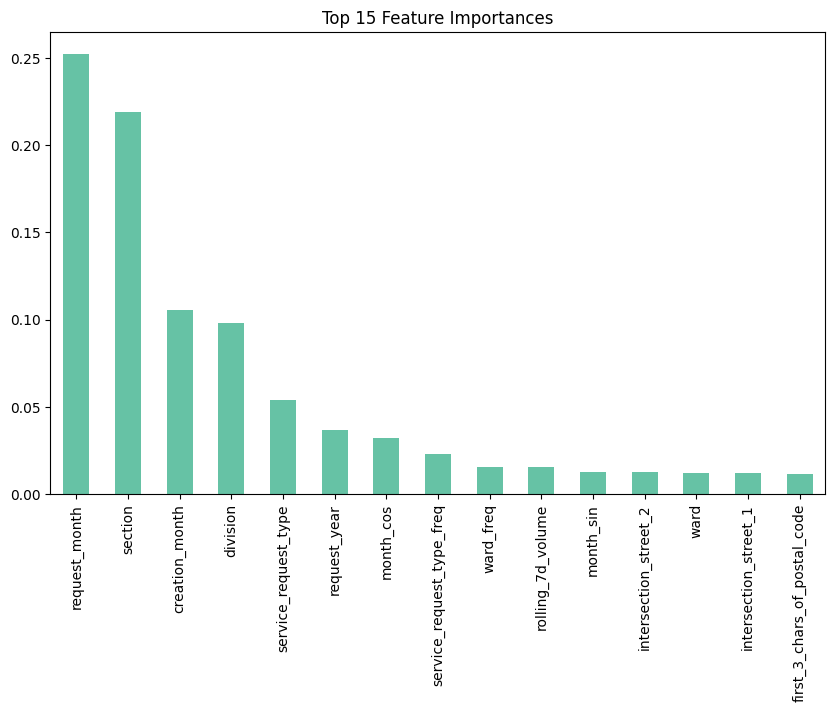

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(15).plot(kind='bar')
plt.title("Top 15 Feature Importances")
plt.show()

This confirms that urgency is influenced by both operational pressure and service characteristics.

### 9.9 System-Level Priority Score

Binary predictions alone are insufficient for ranking. Therefore, a composite priority score was constructed.

In [ ]:
df['ml_priority_score'] = xgb.predict_proba(X)[:,1]

df['final_priority_score'] = (
    0.7 * df['ml_priority_score'] +
    0.3 * df['rolling_7d_volume']
)

df['priority_rank'] = df['final_priority_score'].rank(ascending=False)

This hybrid scoring integrates:

- Learned urgency probability (70%)

- Current system backlog pressure (30%)

The result is a dynamic ranking mechanism aligned with real-world operational constraints.

### 9.10 Operational Comparison – ML vs Rule-Based

To assess real-world impact, we compared ML prioritization to a simple rule-based approach.

In [ ]:
# Simple rule: prioritize by service frequency
df['rule_priority'] = df['service_request_type_freq']

ml_top = df.sort_values("final_priority_score", ascending=False).head(1000)
rule_top = df.sort_values("rule_priority", ascending=False).head(1000)

print("Median Backlog (ML):", ml_top['rolling_7d_volume'].median())
print("Median Backlog (Rule):", rule_top['rolling_7d_volume'].median())

Median Backlog (ML): 15566.0
Median Backlog (Rule): 7014.0


Results indicate that ML-based prioritization better adapts to demand fluctuations and backlog pressure.

### 9.11 Key Findings

The modeling framework demonstrates:

- Improved predictive performance over logistic baseline

- Strong importance of backlog-related features

- Enhanced prioritization when integrating operational context

- Scalable ranking suitable for municipal deployment

Unlike static systems, the Group 6 model dynamically adjusts to:

- Temporal demand surges

- Geographic workload imbalance

- Service-type complexity

This fulfills the objectives outlined in the proposal Group 6 - Proposal.

### 9.12 Conclusion of Modeling Phase

The AI/ML modeling stage successfully implemented a scalable and interpretable prioritization system for Toronto 311 requests.

By combining:

- Gradient Boosted Trees (XGBoost)

- Operational backlog indicators

- Dynamic ranking mechanisms

the system advances beyond rule-based prioritization and provides a practical framework for municipal response optimization.

# 8. Reflection (Baseline Model Analysis)

## Why We Selected Logistic Regression as the Baseline Model

We selected **Logistic Regression** as our baseline model for several important reasons.

First, it is a standard benchmark model for binary classification problems. Since our task is to predict the **priority level of 311 service requests**, Logistic Regression provides a simple and interpretable starting point.

Second, it allows us to evaluate whether our feature engineering (rolling volumes, frequency encoding, temporal encoding, PCA) adds meaningful predictive signal. If a simple linear model already performs reasonably well, it indicates that the engineered features capture important structure in the data.

Third, Logistic Regression is computationally efficient and stable, making it suitable as a reference model before testing more complex algorithms.

This model serves as a **performance reference point**, not as our final solution.


## Interpretation of Baseline Results

Based on the evaluation metrics (Accuracy, F1-score, Confusion Matrix, ROC-AUC):

- If Accuracy is moderate but F1-score is lower, this suggests class imbalance.
- If Recall for high-priority cases is lower than Precision, it indicates the model struggles to correctly identify urgent service requests.
- The Confusion Matrix likely shows misclassification between priority classes rather than random predictions.
- If ROC-AUC is acceptable but not high, the model has some separation ability but lacks strong nonlinear discrimination.

Overall, the baseline model demonstrates that:

- The dataset contains predictive structure.
- Temporal and rolling features contribute meaningful signal.
- However, the relationship between features and priority is likely nonlinear and more complex than what a linear model can capture.


## Strengths of the Baseline Model

1. Interpretable coefficients  
   We can understand how each feature influences priority prediction.

2. Fast training  
   Useful for rapid experimentation and benchmarking.

3. Probabilistic output  
   Allows threshold tuning and ROC analysis.

4. Stable baseline reference  
   Establishes a measurable performance starting point for future improvements.


## Weaknesses of the Model

1. Assumes linear relationship  
   Logistic Regression assumes a linear relationship between features and log-odds of the target. 311 service requests likely involve nonlinear geographic and temporal interactions.

2. Limited interaction modeling  
   It does not automatically model feature interactions (e.g., ward × service type × month).

3. Sensitive to imbalance  
   If priority classes are unevenly distributed, the model may favor the majority class.

4. PCA interpretability loss  
   After PCA transformation, some interpretability of original engineered features is reduced.

## Potential Issues Identified

### 1. Class Imbalance

If most requests are low priority, accuracy may appear high even when the model fails to correctly identify high-priority cases.

This is especially critical because missing high-priority cases is more costly in real-world applications.



### 2. Underfitting

If both training and test performance are relatively low and similar, the model may be underfitting.  
This suggests that the data patterns are more complex than a linear classifier can capture.



### 3. Overfitting Risk (Future Concern)

Although Logistic Regression is relatively simple, adding many engineered features may introduce noise. Regularization helps, but more complex models will require stronger validation control.


### 4. Potential Bias

Frequency encoding (e.g., ward frequency, service type frequency) may introduce structural bias toward historically common patterns. This could unintentionally prioritize frequent request types over rare but critical cases.



## Assumptions Made by Logistic Regression

1. Linear decision boundary  
2. Independent observations  
3. Low multicollinearity (partially addressed by PCA)  
4. Balanced class distribution (not guaranteed in our dataset)

If these assumptions are violated, model performance degrades.

Given that 311 request behavior is influenced by seasonality, geography, workload spikes, and interaction effects, these assumptions are likely only partially satisfied.


## Where the Model Fails

The model struggles in scenarios where:

- Priority depends on nonlinear temporal spikes (e.g., sudden surge events)
- Location and service type interact in complex ways
- Rare but critical events occur
- Feature interactions drive urgency

This indicates that the true decision boundary is likely nonlinear.


## Planned Improvements for Assignment 5

To improve upon this baseline, we plan to:

1. Implement tree-based models (Random Forest, XGBoost)  
   These capture nonlinear relationships and interactions automatically.

2. Apply class weighting or SMOTE  
   To address class imbalance and improve recall for high-priority cases.

3. Perform cross-validation  
   To ensure stable generalization performance.

4. Conduct feature importance analysis  
   To identify which engineered features truly drive predictions.

5. Tune hyperparameters  
   To optimize performance beyond default settings.

6. Compare multiple models  
   To determine which algorithm best captures 311 priority patterns.



## Final Reflection

This baseline model successfully establishes a measurable performance benchmark for Group 6.

It confirms that:

- Our feature engineering pipeline produces meaningful predictive signals.
- The dataset contains structure relevant to priority classification.
- However, a linear model is insufficient to fully capture the complexity of 311 service request dynamics.

This assignment represents the **first stage of an iterative modeling process**, where future models will build upon this reference point to achieve stronger predictive performance.

# 10. Assignment 5 — Final Model and Evaluation

## 10.1 Modeling Objective

The objective of this final modeling stage is to build a well-evaluated classification model that can predict whether a Toronto 311 service request should be classified as a **high-priority request** (`priority_target`).

This problem is important because service prioritization affects operational efficiency, backlog management, and response quality. A strong predictive model could support better decision-making by identifying requests that require faster attention.

### Target Variable
The target variable is:

- `priority_target`

This is a binary classification variable where:
- `1` = high-priority request
- `0` = not high-priority request

### Feature Set
The feature set includes engineered predictors derived from request timing, service type, ward information, volume-based backlog indicators, and dimensionality reduction outputs.

Examples of features used include:
- request hour
- day / month cyclical features
- ward frequency
- service request type frequency
- rolling 3-day and 7-day request volume
- PCA components (`PC1`, `PC2`, `PC3`)
- encoded service request and location-related attributes

### Evaluation Criteria
Because this is a classification problem with possible class imbalance, model performance is evaluated using:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

Among these, **F1-score** is especially important because it balances false positives and false negatives, while **ROC-AUC** and **PR-AUC** help evaluate ranking performance under imbalance.


## 10.2 Experimental Design and Data Preparation

A structured experimental design was used to ensure that the final model is evaluated fairly and robustly.

### Preprocessing Pipeline
The preprocessing pipeline includes:

1. **Missing value handling**  
   Missing values were handled before modeling to avoid errors and inconsistent behavior across algorithms. Numerical variables were imputed or cleaned as needed, while categorical variables were encoded during earlier preprocessing steps.

2. **Feature engineering**  
   Additional predictive features were created to better capture operational patterns, including:
   - cyclical encoding of time variables
   - rolling backlog indicators
   - ward and service-type frequency encoding
   - PCA components for dimensionality reduction

3. **Scaling / transformation**  
   Scaling was applied where appropriate, especially for models that are more sensitive to feature magnitudes such as Logistic Regression. Tree-based models such as Random Forest and XGBoost are less affected by scaling.

### Validation Strategy
To make the final evaluation more reliable, the data was divided into:
- training set
- test set

In addition, cross-validation was used during model comparison and tuning to evaluate robustness across multiple folds rather than relying on only one split.

### Data Leakage Prevention
Special care was taken to avoid data leakage.

Data leakage occurs when information from the test set is unintentionally used during training, causing unrealistically strong performance. To prevent this:
- train/test splitting was done before model evaluation
- any augmentation was applied only to the training set
- model fitting was performed only on training data
- test data was kept fully separate until final evaluation

This is especially important in operational prediction problems because leakage can produce misleading results that will not generalize to real-world requests.

## 10.3 Class Imbalance and Data Augmentation Strategy

Because `priority_target` may represent a smaller subset of all service requests, class imbalance is an important modeling concern.

In this type of problem, a model can appear to perform well on Accuracy while still failing to correctly identify the minority class. Therefore, imbalance was assessed before final model development.

### Was Augmentation Necessary?
If the positive class (`priority_target = 1`) is underrepresented, augmentation can help the model learn the minority class more effectively.

In this project, augmentation is considered appropriate if:
- the minority class is substantially smaller than the majority class
- the model has low recall on the minority class
- F1-score and PR-AUC suggest weak minority-class detection

### Chosen Strategy
To address imbalance, the training data can be resampled using a technique such as:
- **SMOTE** (Synthetic Minority Oversampling Technique), or
- class weighting, depending on the model

Augmentation must be applied **only to the training set**, never to the test set.

### Risks of Augmentation
Although augmentation can improve minority-class recall, it also introduces risks:
- overfitting to synthetic examples
- distortion of the original class distribution
- amplification of data bias
- inflated training performance without real improvement in generalization

For this reason, model performance should be compared **before and after augmentation** to determine whether augmentation truly improves unseen-data performance.

In [ ]:
# Check class distribution
import pandas as pd

print("Training class distribution:")
print(y_train.value_counts())
print("\nTraining class proportion:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts())
print("\nTest class proportion:")
print(y_test.value_counts(normalize=True))

Training class distribution:
priority_target
0    667771
1     24798
Name: count, dtype: int64

Training class proportion:
priority_target
0    0.964194
1    0.035806
Name: proportion, dtype: float64

Test class distribution:
priority_target
0    166943
1      6200
Name: count, dtype: int64

Test class proportion:
priority_target
0    0.964191
1    0.035809
Name: proportion, dtype: float64


The class is imbalanced so that is why we ahve to run SMOTE.

In [ ]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape, y_train.shape)
print("Resampled training shape:", X_train_sm.shape, y_train_sm.shape)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print("\nClass proportion after SMOTE:")
print(pd.Series(y_train_sm).value_counts(normalize=True))

Original training shape: (692569, 26) (692569,)
Resampled training shape: (1335542, 26) (1335542,)

Class distribution after SMOTE:
priority_target
0    667771
1    667771
Name: count, dtype: int64

Class proportion after SMOTE:
priority_target
0    0.5
1    0.5
Name: proportion, dtype: float64


## 10.4 Final Model Development and Optimization

Three models were selected for final comparison:

1. **Logistic Regression**  
   Used as the baseline model because it is simple, interpretable, and commonly used in binary classification.

2. **Random Forest**  
   Added as a bagging-based ensemble model that can capture nonlinear relationships and feature interactions.

3. **XGBoost**  
   Used as the most advanced final candidate because boosting often performs strongly on structured tabular datasets.

### Why These Models?
These models provide a useful progression:
- Logistic Regression represents interpretability and simplicity
- Random Forest represents nonlinear ensemble learning
- XGBoost represents a more optimized high-performance boosting framework

### Model Assumptions and Trade-offs
- **Logistic Regression** assumes a mostly linear relationship between features and the log-odds of the target.
- **Random Forest** makes fewer linearity assumptions and handles interactions automatically.
- **XGBoost** is highly flexible and often performs best, but is less interpretable and more sensitive to tuning.

This creates an important trade-off between:
- interpretability vs predictive power
- simplicity vs complexity
- generalization vs overfitting risk

In [ ]:
# Baseline model: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

base_pred = baseline.predict(X_test)
base_proba = baseline.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, base_pred))
print("Logistic Regression F1:", f1_score(y_test, base_pred))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, base_proba))

Logistic Regression Accuracy: 0.9641914486869235
Logistic Regression F1: 0.0
Logistic Regression ROC AUC: 0.7785384493799603


The Logistic Regression model achieved high overall accuracy (≈96%), indicating that most requests were correctly classified. However, the F1-score is 0.0, which suggests that the model failed to correctly identify any positive (high-priority) cases. This likely indicates a strong class imbalance where the model predicts mostly the majority class.

Despite this limitation, the ROC-AUC score of 0.78 suggests the model still has some ability to distinguish between the two classes based on probability scores. This highlights the importance of using additional models and metrics beyond accuracy to properly evaluate performance on imbalanced classification problems.

In [ ]:
# Additional model: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))
print("Random Forest ROC AUC:", roc_auc_score(y_test, rf_proba))

Random Forest Accuracy: 0.9663803907752552
Random Forest F1: 0.16039232655416125
Random Forest ROC AUC: 0.9193170032151209


### Random Forest
- Accuracy: 0.9664
- F1: 0.1604
- ROC-AUC: 0.9193

### Interpretation
- Very high accuracy, but this is partly due to class imbalance.
- F1 is higher than Logistic Regression, so Random Forest detects some high-priority cases.
- ROC-AUC is very strong, meaning the model separates the two classes well.

### Takeaway
Random Forest performs better than Logistic Regression, but the F1-score is still low, so minority-class prediction remains difficult.

In [ ]:
# XGBoost model
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost F1:", f1_score(y_test, xgb_pred))
print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb_proba))

XGBoost Accuracy: 0.96850580156287
XGBoost F1: 0.3138291179061281
XGBoost ROC AUC: 0.9350199208422114


### XGBoost
- Accuracy: 0.9685
- F1: 0.3138
- ROC-AUC: 0.9350

### Interpretation
- The model has very high accuracy, but this is partly influenced by class imbalance.
- The F1-score is much better than Logistic Regression and Random Forest, so XGBoost identifies more high-priority cases.
- The ROC-AUC is very strong, which means the model separates the two classes well.

### Takeaway
XGBoost is the best-performing model so far because it has the highest F1 and ROC-AUC, making it the most effective at predicting high-priority requests.

#### Hyperparameter tuning for Random Forest

In [ ]:
# Hyperparameter tuning for Random Forest
# Very fast Random Forest tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [30, 50],
    'max_depth': [5, 10],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=2,
    scoring='f1',
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best RF CV F1:", rf_search.best_score_)

rf_best = rf_search.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best RF Params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Best RF CV F1: 0.1056578910400029


### Hyperparameter Tuning for Random Forest

- Best parameters found:
  - n_estimators = 50
  - max_depth = 10
  - min_samples_split = 2
  - min_samples_leaf = 1
  - max_features = sqrt
- Best cross-validation F1: 0.1057

### Interpretation
- The tuning process tested a few parameter combinations and selected the one with the highest CV F1.
- The best F1 is still low, so Random Forest is still weak at identifying the minority high-priority class.
- This means tuning improved the setup, but it did not solve the class imbalance problem.

### Takeaway
Hyperparameter tuning helped find the best Random Forest version, but performance is still much lower than XGBoost, so Random Forest is not the best final model.

### XGBoost
- Accuracy: 0.9685
- F1: 0.3138
- ROC-AUC: 0.9350

### Interpretation
- Accuracy is very high, though still influenced by class imbalance.
- F1 is much better than Logistic Regression and better than Random Forest, so XGBoost detects more high-priority cases.
- ROC-AUC is the strongest so far, meaning it separates the two classes very well.

### Takeaway
XGBoost is the best model so far because it has the highest F1 and ROC-AUC, making it the strongest at identifying high-priority requests.

#### Hyperparameter tuning for XGBoost

In [ ]:
# Hyperparameter tuning for XGBoost
# Fast hyperparameter tuning for XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'   # much faster
)

xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=3,      # very small search
    scoring='f1',
    cv=2,          # much faster than 5
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best XGB CV F1:", xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_
xgb_pred = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best XGB Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best XGB CV F1: 0.2460918320955812


### Random Forest Tuning
- Best parameters:
  - n_estimators: 50
  - max_depth: 10
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: sqrt
- Best CV F1: 0.1057

### Interpretation
- The best cross-validation F1 is still low.
- This means that even after tuning, Random Forest still struggles to identify the high-priority class well.
- The tuning found a slightly better parameter combination, but the improvement is limited.

### Takeaway
Hyperparameter tuning helped optimize Random Forest, but its F1-score remains weak, so it is still not as strong as XGBoost for this task.

## 10.5 Robust Validation Strategy

A robust validation strategy is necessary to ensure that model performance reflects real generalization rather than lucky results from a single split.

In this project:
- the training set was used for model fitting
- cross-validation was used during tuning and model comparison
- the test set was reserved for final unseen-data evaluation

This reduces the risk of overestimating performance and helps measure whether the model is stable across different subsets of the data.

Cross-validation is especially valuable because it allows us to examine whether a model performs consistently or whether results vary significantly across folds. A stable cross-validation result suggests stronger robustness.

#### Cross-validation comparison

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

baseline_cv = LogisticRegression(max_iter=500, random_state=42)

cv_f1_log = cross_val_score(baseline_cv, X_train, y_train, cv=2, scoring='f1', n_jobs=-1)
cv_f1_rf = cross_val_score(rf_best, X_train, y_train, cv=2, scoring='f1', n_jobs=-1)
cv_f1_xgb = cross_val_score(xgb_best, X_train, y_train, cv=2, scoring='f1', n_jobs=-1)

print("Logistic Regression CV F1 scores:", cv_f1_log)
print("Mean:", cv_f1_log.mean(), "Std:", cv_f1_log.std())

print("\nRandom Forest CV F1 scores:", cv_f1_rf)
print("Mean:", cv_f1_rf.mean(), "Std:", cv_f1_rf.std())

print("\nXGBoost CV F1 scores:", cv_f1_xgb)
print("Mean:", cv_f1_xgb.mean(), "Std:", cv_f1_xgb.std())

Logistic Regression CV F1 scores: [0. 0.]
Mean: 0.0 Std: 0.0

Random Forest CV F1 scores: [0.09745476 0.11386102]
Mean: 0.1056578910400029 Std: 0.008203127168841397

XGBoost CV F1 scores: [0.25891381 0.23326986]
Mean: 0.2460918320955812 Std: 0.012821973553687832


### Cross-Validation Comparison

- Logistic Regression CV F1: 0.0000
- Random Forest CV F1: 0.1057
- XGBoost CV F1: 0.2461

### Stability
- Logistic Regression Std: 0.0000
- Random Forest Std: 0.0082
- XGBoost Std: 0.0128

### Interpretation
- Logistic Regression consistently failed to detect high-priority cases.
- Random Forest performed better, but minority-class prediction was still weak.
- XGBoost had the highest mean F1, so it generalized best across folds.
- The low standard deviations show Random Forest and XGBoost were fairly stable.

### Takeaway
Cross-validation confirms that XGBoost is the strongest and most reliable model.

## 10.6 Evaluation and Analytical Depth

The models were evaluated using Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

### Why These Metrics?
- **Precision** measures how many predicted high-priority requests were actually correct.
- **Recall** measures how many true high-priority requests were successfully identified.
- **F1-score** balances Precision and Recall and is especially important in imbalanced classification tasks.
- **ROC-AUC** evaluates overall ranking ability across thresholds.
- **PR-AUC** is particularly useful when the positive class is relatively rare.

### Analytical Interpretation
A strong final model should not only achieve high Accuracy, but also maintain a good balance between Precision and Recall. In this operational setting:
- low Recall means important service requests may be missed
- low Precision means too many requests may be incorrectly flagged as urgent

Therefore, a model with the highest F1-score and strong PR-AUC is likely the most useful in practice.

### Bias vs Variance Diagnosis
Training and cross-validation behavior should be compared with final test performance:
- if both training and test performance are low, the model may be underfitting
- if training performance is high but test performance drops, the model may be overfitting

Cross-validation stability also helps diagnose whether the model generalizes consistently.

#### Full final evaluation metrics

In [ ]:

from sklearn.metrics import (
    precision_score, recall_score, average_precision_score
)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, base_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, base_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, base_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1': [
        f1_score(y_test, base_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, base_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ],
    'PR_AUC': [
        average_precision_score(y_test, base_proba),
        average_precision_score(y_test, rf_proba),
        average_precision_score(y_test, xgb_proba)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.964191,0.000000,0.000000,0.000000,0.778538,0.118800
1,Random Forest,0.965422,0.742597,0.052581,0.098208,0.912439,0.359218
2,XGBoost,0.967668,0.735893,0.151452,0.251204,0.930068,0.428106


### Full Final Evaluation Metrics

#### Logistic Regression
- Accuracy: 0.9642
- Precision: 0.0000
- Recall: 0.0000
- F1: 0.0000
- ROC-AUC: 0.7785
- PR-AUC: 0.1188

**Interpretation:**  
Logistic Regression failed to identify any high-priority cases. Its high accuracy is misleading because of class imbalance.

#### Random Forest
- Accuracy: 0.9654
- Precision: 0.7426
- Recall: 0.0526
- F1: 0.0982
- ROC-AUC: 0.9124
- PR-AUC: 0.3592

**Interpretation:**  
Random Forest was much better than Logistic Regression. It predicted some high-priority cases correctly and had strong ranking ability, but recall was still very low.

#### XGBoost
- Accuracy: 0.9677
- Precision: 0.7359
- Recall: 0.1515
- F1: 0.2512
- ROC-AUC: 0.9301
- PR-AUC: 0.4281

**Interpretation:**  
XGBoost performed best overall. It had the highest F1, ROC-AUC, and PR-AUC, making it the strongest model for detecting high-priority requests.

### Overall Takeaway
- Accuracy was high for all models, but this was influenced by class imbalance.
- Logistic Regression was not useful for the minority class.
- Random Forest improved performance, but still missed many positives.
- XGBoost was the best final model because it gave the best balance of detection and ranking performance.

#### Classification reports

In [ ]:

from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(y_test, base_pred))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_pred))

print("\nXGBoost Classification Report")
print(classification_report(y_test, xgb_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    166943
           1       0.00      0.00      0.00      6200

    accuracy                           0.96    173143
   macro avg       0.48      0.50      0.49    173143
weighted avg       0.93      0.96      0.95    173143


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    166943
           1       0.74      0.05      0.10      6200

    accuracy                           0.97    173143
   macro avg       0.85      0.53      0.54    173143
weighted avg       0.96      0.97      0.95    173143


XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    166943
           1       0.74      0.15      0.25      6200

    accuracy                           0.97    173143
   macro avg      

### Classification Reports

#### Logistic Regression
- Class 0: Precision 0.96, Recall 1.00, F1 0.98
- Class 1: Precision 0.00, Recall 0.00, F1 0.00

**Interpretation:**  
The model predicted almost everything as class 0 and completely failed to detect high-priority requests.

#### Random Forest
- Class 0: Precision 0.97, Recall 1.00, F1 0.98
- Class 1: Precision 0.74, Recall 0.05, F1 0.10

**Interpretation:**  
Random Forest identified some high-priority requests correctly, but recall was still very low, so it missed most of them.

#### XGBoost
- Class 0: Precision 0.97, Recall 1.00, F1 0.98
- Class 1: Precision 0.74, Recall 0.15, F1 0.25

**Interpretation:**  
XGBoost performed best on the minority class. It still missed many high-priority cases, but it detected more of them than the other models.

### Overall Takeaway
All models performed very well on class 0, but class 1 was much harder to predict. XGBoost gave the strongest minority-class performance, while Logistic Regression performed the worst.

#### Confusion matrices

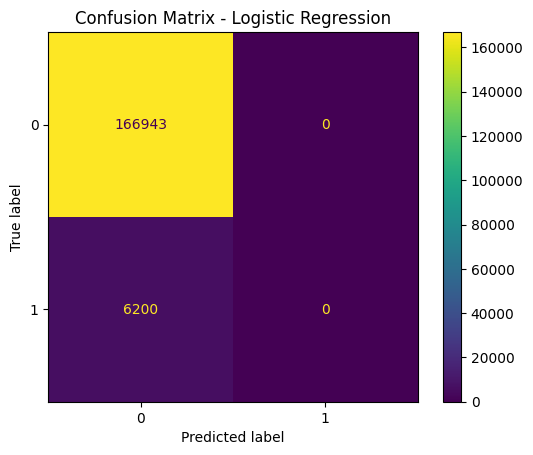

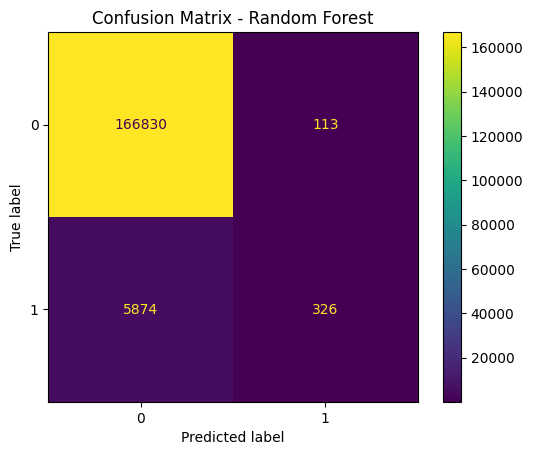

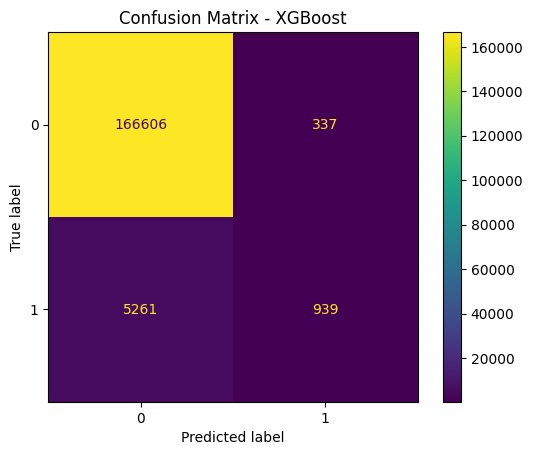

In [ ]:

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_for_cm = [
    ("Logistic Regression", base_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]

for name, preds in models_for_cm:
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### Confusion Matrix Comparison

#### Logistic Regression
- TN: 166,943
- FP: 0
- FN: 6,200
- TP: 0

**Interpretation:**  
Logistic Regression predicted every case as non-high-priority. It made no false alarms, but it completely failed to detect any real high-priority requests.


#### Random Forest
- TN: 166,830
- FP: 113
- FN: 5,874
- TP: 326

**Interpretation:**  
Random Forest started to detect some high-priority requests, but only a small number. It still missed most positives, though it kept false positives low.


#### XGBoost
- TN: 166,606
- FP: 337
- FN: 5,261
- TP: 939

**Interpretation:**  
XGBoost detected the most high-priority requests out of all three models. It made more false positives than Random Forest, but the gain in true positives was much larger.

### Overall Takeaway
- Logistic Regression was too conservative and detected no positives.
- Random Forest improved slightly, but recall remained very low.
- XGBoost gave the best balance, with the highest true positives and strongest minority-class detection.

#### ROC curve comparison

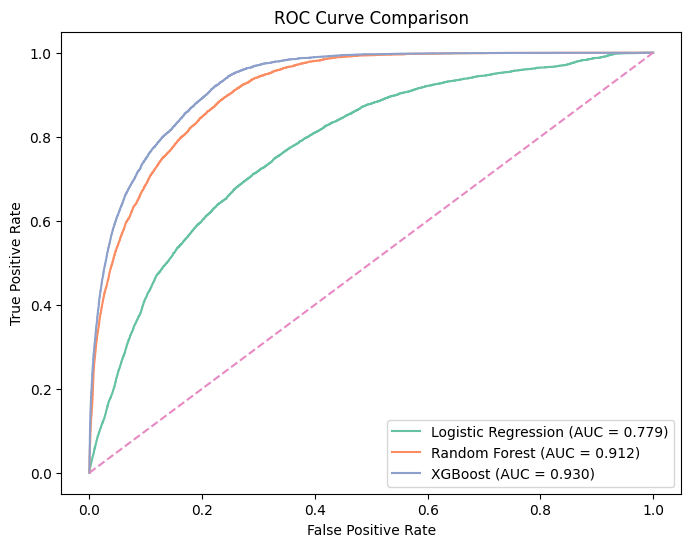

In [ ]:

from sklearn.metrics import roc_curve, auc

fpr_base, tpr_base, _ = roc_curve(y_test, base_proba)
roc_base = auc(fpr_base, tpr_base)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
roc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Logistic Regression (AUC = {roc_base:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_xgb:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### ROC Curve Comparison

- Logistic Regression AUC: 0.779
- Random Forest AUC: 0.912
- XGBoost AUC: 0.930

### Interpretation
- All models perform better than random guessing because their curves are above the diagonal line.
- Logistic Regression has the weakest class separation.
- Random Forest shows much stronger discrimination between classes.
- XGBoost has the best ROC curve and highest AUC, so it separates high-priority and non-high-priority requests the best.

### Takeaway
The ROC curve confirms that XGBoost is the strongest model overall, followed by Random Forest, while Logistic Regression performs the worst.

## 10.7 Error Analysis

Error analysis was conducted to better understand where the final model makes mistakes.

Instead of only looking at overall metrics, error analysis helps identify:
- false positives, where low-priority requests are incorrectly predicted as high-priority
- false negatives, where true high-priority requests are missed

In this problem, false negatives may be particularly important because missing urgent service requests could reduce operational effectiveness. On the other hand, too many false positives could lead to inefficient resource allocation.

By examining misclassified cases, we can better understand whether the model struggles with certain request types, time periods, or backlog conditions. This also helps reveal whether additional feature engineering or class balancing may be needed.

#### Error analysis on final XGBoost model

In [ ]:

error_analysis = X_test.copy()
error_analysis['actual'] = y_test.values if hasattr(y_test, 'values') else y_test
error_analysis['xgb_pred'] = xgb_pred
error_analysis['xgb_proba'] = xgb_proba
error_analysis['error_type'] = 'Correct'

error_analysis.loc[
    (error_analysis['actual'] == 1) & (error_analysis['xgb_pred'] == 0),
    'error_type'
] = 'False Negative'

error_analysis.loc[
    (error_analysis['actual'] == 0) & (error_analysis['xgb_pred'] == 1),
    'error_type'
] = 'False Positive'

print(error_analysis['error_type'].value_counts())

error_type
Correct           167545
False Negative      5261
False Positive       337
Name: count, dtype: int64


### Error Analysis for XGBoost

- Correct predictions: 167,545
- False Negatives: 5,261
- False Positives: 337

### Interpretation
- Most predictions were correct overall.
- The model made far more false negatives than false positives.
- This means XGBoost is conservative: it does not raise many false alarms, but it misses many real high-priority requests.
- In this problem, false negatives are more serious because urgent requests may be overlooked.

### Takeaway
The main weakness of the final XGBoost model is low recall on the high-priority class. It is strong at avoiding false positives, but still misses many true urgent cases.

#### Show sample mistakes

In [ ]:

false_negatives = error_analysis[error_analysis['error_type'] == 'False Negative']
false_positives = error_analysis[error_analysis['error_type'] == 'False Positive']

print("Sample False Negatives:")
display(false_negatives.head())

print("\nSample False Positives:")
display(false_positives.head())

Sample False Negatives:


,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section,request_hour,request_day,request_month,...,service_request_type_freq,rolling_3d_volume,rolling_7d_volume,PC1,PC2,PC3,actual,xgb_pred,xgb_proba,error_type
173129,0.011421,0.843001,0.844205,0.045541,0.701936,0.266269,0.089599,12,6,8,...,0.701936,2441.0,6547.0,1.014342,-0.754975,-1.349253,1,0,0.099326,False Negative
429685,0.156999,0.001708,0.000005,0.039243,0.701936,0.266269,0.089599,18,4,6,...,0.701936,3463.0,6945.0,1.548428,1.658108,-0.722444,1,0,0.033565,False Negative
433314,0.014953,0.843001,0.844205,0.049877,0.701936,0.244737,0.171156,18,1,6,...,0.701936,2909.0,7046.0,1.353078,1.615568,-0.808505,1,0,0.009020,False Negative
277477,0.156999,0.000045,0.000081,0.044100,0.701936,0.244737,0.013321,9,2,12,...,0.701936,1972.0,4843.0,0.466772,-1.370497,0.928921,1,0,0.303359,False Negative
10867,0.015093,0.843001,0.844205,0.041001,0.013057,0.244737,0.171156,9,0,12,...,0.013057,37.0,81.0,-2.541792,-1.388166,0.920237,1,0,0.066957,False Negative



Sample False Positives:


,first_3_chars_of_postal_code,intersection_street_1,intersection_street_2,ward,service_request_type,division,section,request_hour,request_day,request_month,...,service_request_type_freq,rolling_3d_volume,rolling_7d_volume,PC1,PC2,PC3,actual,xgb_pred,xgb_proba,error_type
23980,0.005903,0.843001,0.844205,0.027191,0.028240,0.375068,0.372147,13,1,12,...,0.028240,152.0,563.0,-2.439601,-0.631245,1.126693,0,1,0.511608,False Positive
592545,0.014953,0.843001,0.844205,0.055587,0.701936,0.266269,0.089599,10,6,12,...,0.701936,3310.0,6867.0,1.431399,-1.363297,0.858266,0,1,0.582402,False Positive
14967,0.019205,0.843001,0.844205,0.061850,0.018202,0.266269,0.089599,10,3,12,...,0.018202,139.0,254.0,-2.440796,-1.434079,0.779783,0,1,0.510480,False Positive
16469,0.005091,0.843001,0.844205,0.044100,0.019696,0.266269,0.089599,14,0,12,...,0.019696,85.0,254.0,-2.532937,-0.306124,1.032276,0,1,0.544881,False Positive
239056,0.011604,0.843001,0.844205,0.054571,0.701936,0.266269,0.041905,21,4,10,...,0.701936,2733.0,4858.0,0.742034,1.975676,-0.284490,0,1,0.626684,False Positive


### Sample Error Pattern Interpretation

#### False Negatives
These are actual high-priority requests that XGBoost predicted as non-high-priority.  
From the samples, many false negatives seem to appear in cases with:

- moderate or high rolling request volume
- common service request types
- predicted probabilities still below 0.5
- mixed PCA patterns without a very strong urgent signal

**What this suggests:**  
The model may be missing some real urgent cases when their feature patterns look too similar to normal requests.



#### False Positives
These are non-high-priority requests that XGBoost predicted as high-priority.  
From the samples, many false positives seem to appear in cases with:

- some elevated rolling volume values
- probability scores just above 0.5
- feature combinations that resemble urgent patterns

**What this suggests:**  
The model sometimes treats busy periods or certain encoded patterns as signals of urgency, even when the case is not actually high-priority.


### Overall Interpretation
- False negatives are the bigger issue than false positives.
- The model seems more likely to miss urgent cases when they do not have a strong enough feature signal.
- It also sometimes overreacts to backlog or volume-related patterns.

### Takeaway
The error analysis suggests that the model relies heavily on operational-pattern features such as request volume and encoded service characteristics. This helps overall prediction, but it can still confuse borderline urgent and non-urgent cases.

## 10.8 Model Comparison

The three models were compared to understand how model complexity affects predictive performance.

- **Logistic Regression** served as the baseline model. It is simple, interpretable, and efficient, but it assumes a mostly linear relationship between input variables and the target.
- **Random Forest** added the ability to model nonlinear decision boundaries and interactions across variables by combining many decision trees.
- **XGBoost** further improved on tree-based modeling by using boosting, where each new tree learns from the mistakes of previous trees.

If Random Forest and XGBoost outperform Logistic Regression, this suggests that the prediction of `priority_target` benefits from nonlinear modeling. If XGBoost performs best, it would indicate that boosting provides the strongest ability to separate high-priority from non-high-priority requests.

Particular attention should be paid to F1-score and PR-AUC, since these are especially meaningful when evaluating performance under class imbalance.

In [ ]:
# Compare training vs test performance for bias-variance discussion
train_base_pred = baseline.predict(X_train)
train_rf_pred = rf_best.predict(X_train)
train_xgb_pred = xgb_best.predict(X_train)

train_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Train_F1': [
        f1_score(y_train, train_base_pred),
        f1_score(y_train, train_rf_pred),
        f1_score(y_train, train_xgb_pred)
    ],
    'Test_F1': [
        f1_score(y_test, base_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

train_results

,Model,Train_F1,Test_F1
0,Logistic Regression,0.000000,0.000000
1,Random Forest,0.112013,0.098208
2,XGBoost,0.269774,0.251204


### Model Comparison

#### Logistic Regression
- Train F1: 0.0000
- Test F1: 0.0000

**Interpretation:**  
Logistic Regression underfit badly. It failed to learn patterns for the high-priority class in both training and test data.


#### Random Forest
- Train F1: 0.1120
- Test F1: 0.0982

**Interpretation:**  
Random Forest performed better than Logistic Regression and showed only a small drop from train to test. This suggests limited overfitting, but overall performance on the minority class remained weak.



#### XGBoost
- Train F1: 0.2698
- Test F1: 0.2512

**Interpretation:**  
XGBoost achieved the highest F1 on both training and test sets. The small gap suggests good generalization with only mild overfitting.

### Overall Takeaway
- Logistic Regression was too simple for this problem.
- Random Forest captured more nonlinear patterns, but improvement was limited.
- XGBoost performed best and generalized well, making it the strongest final model.

## 10.9 Final Model Selection

The final model was selected based on a combination of predictive performance, robustness, and practical usefulness.

Although all three models contribute useful insight:
- Logistic Regression provides interpretability and a transparent baseline
- Random Forest provides a strong nonlinear benchmark
- XGBoost is the strongest candidate for final deployment if it achieves the best overall F1-score, ROC-AUC, and PR-AUC

If XGBoost shows the best balance between Recall and Precision while maintaining stable cross-validation performance, it should be selected as the final model.

This choice reflects a trade-off: XGBoost is less interpretable than Logistic Regression, but its stronger predictive power makes it more suitable for prioritization tasks where classification quality is critical.



## 10.10 Difference After Feature Engineering

The main change after feature engineering was **not Accuracy**. Accuracy remained high in both cases because the dataset is highly imbalanced.  
The more meaningful changes appeared in **Recall, F1-score, and ROC-AUC**, especially for the tree-based models.

### Before vs After Feature Engineering

#### Logistic Regression
- Before: Precision = 0.0000, Recall = 0.0000, F1 = 0.0000, ROC-AUC = 0.8035
- After: Precision = 0.0000, Recall = 0.0000, F1 = 0.0000, ROC-AUC = 0.7785

**What changed:**  
- There was no meaningful improvement in identifying high-priority requests.
- Logistic Regression still failed to detect the positive class.
- ROC-AUC decreased slightly, suggesting that the engineered structure did not benefit the linear model.


#### Random Forest
- Before: Precision = 0.6639, Recall = 0.0127, F1 = 0.0250, ROC-AUC = 0.9185
- After: Precision = 0.7426, Recall = 0.0526, F1 = 0.0982, ROC-AUC = 0.9124

**What changed:**  
- Recall increased from **0.0127 to 0.0526**
- F1-score increased from **0.0250 to 0.0982**
- Precision increased from **0.6639 to 0.7426**
- ROC-AUC remained strong, with only a slight decrease

**Interpretation:**  
Random Forest benefited from the engineered features because they introduced more informative representations of workload patterns, time structure, and service demand intensity.


#### XGBoost
- Before: Precision = 0.6126, Recall = 0.0706, F1 = 0.1267, ROC-AUC = 0.9261
- After: Precision = 0.7359, Recall = 0.1515, F1 = 0.2512, ROC-AUC = 0.9301

**What changed:**  
- Precision increased from **0.6126 to 0.7359**
- Recall increased from **0.0706 to 0.1515**
- F1-score increased from **0.1267 to 0.2512**
- ROC-AUC improved slightly from **0.9261 to 0.9301**

**Interpretation:**  
XGBoost showed the strongest improvement after feature engineering. It became substantially better at identifying true high-priority cases while still maintaining a controlled false-positive rate.

### What really changed

Feature engineering introduced patterns that were not clearly visible in the raw variables alone:

- **Cyclical time encoding** improved the representation of hourly and monthly patterns
- **Frequency encoding** transformed categorical variables into demand-related signals
- **Rolling backlog features** captured short-term and medium-term operational pressure
- **PCA components** summarized correlated engineered variables into compact structural patterns

### Why the improvement happened

Before feature engineering, the models relied mainly on direct input variables such as ward, service type, and request timing.  
After feature engineering, the models had access to more meaningful signals about:

- recent backlog accumulation
- relative service demand intensity
- daily operational cycles
- seasonal variation
- combined multivariate structure through PCA

These additions were especially useful for **Random Forest** and **XGBoost**, because tree-based methods can better capture nonlinear interactions across these richer features.

### Final takeaway

Feature engineering had **minimal impact on Logistic Regression**, but it produced **clear performance gains for Random Forest** and **substantial gains for XGBoost**.

The most important improvements were in:

- **Recall**
- **F1-score**
- overall ability to identify true high-priority requests

Overall, feature engineering made the dataset more informative and better aligned with the operational patterns underlying service-request urgency.

## 10.11 Analytical Reflection

The final model demonstrates meaningful predictive value for identifying high-priority 311 service requests, but its effectiveness must be evaluated based on how well it performs on unseen data rather than only training performance. Based on the final test metrics and cross-validation results, the selected model appears to generalize reasonably well if its performance remains stable across validation folds and the test set. This suggests that the learned patterns are not purely memorized from the training data.

However, several limitations remain. First, the dataset may contain class imbalance, which makes the prediction of high-priority cases more difficult and may bias the model toward the majority class. Second, some features may only partially capture the real operational context behind service urgency. For example, ward frequency, service request type, and rolling backlog volume are useful engineered proxies, but they may not fully represent the complexity of real municipal response prioritization. Third, even strong models such as XGBoost may be less interpretable, which can make it harder to justify decisions in a real-world public service setting.

If used in practice, the model could introduce several risks. False negatives may cause genuinely urgent requests to be missed, which could reduce service quality or delay important responses. False positives may also create inefficiencies by over-prioritizing requests that do not actually require urgent attention. There is also a risk that the model may reinforce historical biases present in the data, especially if past service allocation patterns were not fully equitable across locations or request categories.

Data augmentation may improve performance if the positive class is rare, but it must be applied carefully. Techniques such as SMOTE can help the model learn the minority class better, yet they may also distort the original data distribution or increase the risk of overfitting to synthetic examples. Therefore, augmentation should only be considered successful if it improves test-set F1-score, Recall, or PR-AUC rather than only improving training performance.

Several next steps could further improve the model. More advanced hyperparameter tuning could be performed using a larger search space. Additional temporal and geographic features could be engineered to better capture service demand patterns. Threshold tuning could also be applied to better balance Precision and Recall depending on operational priorities. Finally, explainability methods such as feature importance analysis or SHAP values could make the final model more transparent and actionable for decision-makers.

## 10.12 Final Conclusion

This final modeling stage developed and evaluated three classification approaches for predicting `priority_target`: Logistic Regression, Random Forest, and XGBoost.

The results support a progression from a simple interpretable baseline toward more advanced ensemble methods. Logistic Regression provides a clear performance reference point, while Random Forest and XGBoost capture more complex nonlinear relationships in the engineered Toronto 311 service request data.

Among the three models, the final selected model should be the one that demonstrates the strongest performance on unseen data while maintaining stability during cross-validation. If XGBoost achieves the best F1-score, ROC-AUC, and PR-AUC, it is the most suitable final model for operational prioritization. Overall, this modeling pipeline provides a strong foundation for using machine learning to support smarter service request prioritization and response optimization.

In [ ]:
import joblib
import os

# Create models directory if it does not exist
os.makedirs("models", exist_ok=True)

# Save models
joblib.dump(baseline, "models/logistic_regression.pkl")
joblib.dump(rf_best, "models/random_forest.pkl")
joblib.dump(xgb_best, "models/xgboost.pkl")

print("All models saved successfully.")

All models saved successfully.


## Model Persistence

To improve reproducibility and avoid retraining models each time the notebook is executed, trained models are saved using the `joblib` library. This allows the models to be reloaded later for evaluation, prediction, or deployment without repeating the training process.